# 사과 품질 분류와 품질 관련 요인 분석

**작성자:** bolly0809-coder | **결과 점검일:** 2026-09-03

사과 4,000건의 수치형 특성 7개로 good/bad 품질을 분석했다. 단독 집단 비교와 직선항 로지스틱 회귀에서 뚜렷하지 않았던 **Crunchiness의 곡선 관계**를 가정 진단 과정에서 확인했다. 가정 반영 후 표본 내 정확도는 **74.9% → 79.2%**, ROC-AUC는 **0.824 → 0.868**로 개선됐다.

최종 선택은 **4_가정반영**이다. 제곱항과 그 짝인 1차항을 함께 유지하는 계층 원칙을 적용해, 원변수 7개를 13개 설명항으로 표현했다. 임계값 0.5에서 정확도 **79.18%**, 정밀도 **78.52%**, 재현율 **80.44%**, F1 **0.795**, ROC-AUC **0.868**을 기록했다. 모두 학습에 사용한 동일 표본에서 평가한 결과이며, 새로운 사과에 대한 검증 성능이나 인과효과를 의미하지 않는다.

[프로젝트 요약 · 핵심 결과 · 참고자료 · 회고](README.md)

## 구성

- [1. 데이터 품질 점검과 탐색적 분석](#stage-1)
- [2. 로지스틱 회귀·가정 진단·모형 비교·해석](#stage-2)
- [3. 종합 결과 해석](#conclusion)

## 공개 파일과 재실행 안내

- 공개 파일은 **README와 이 단일 노트북**이다. 실행된 표·그래프·분석 해석은 노트북 안에 포함되어 있어 결과 열람에 재실행이 필요하지 않다.
- helpers·데이터 파일·모델 파일은 공개 폴더에 포함하지 않는다.
- 재실행에는 별도로 보유한 호환 helpers, jussam 및 관련 분석 패키지가 필요하다. 실행 환경에 맞게 첫 경로 설정 셀을 확인하고 커널을 재시작한다.



In [1]:
# 프로젝트 폴더 안의 helpers와 상대 저장 경로를 사용한다.
from pathlib import Path
import os
import sys

project_dir = Path.cwd()
if not (project_dir / "apple-quality-classification.ipynb").is_file():
    project_dir = project_dir / "kaggle프로젝트" / "Apple Quality 사과 품질 분류"
if not (project_dir / "apple-quality-classification.ipynb").is_file():
    raise FileNotFoundError("이 노트북이 있는 프로젝트 폴더에서 실행해 주세요.")
if "helpers" in sys.modules:
    loaded_helpers = Path(sys.modules["helpers"].__file__).resolve().parent
    if loaded_helpers != (project_dir / "helpers").resolve():
        raise RuntimeError("다른 프로젝트의 helpers가 로드되어 있습니다. 커널을 재시작해 주세요.")
os.chdir(project_dir)
sys.path.insert(0, str(project_dir))
print("작업 폴더:", project_dir)


작업 폴더: c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\Apple Quality 사과 품질 분류


<a id="stage-1"></a>

## 1. 데이터 품질 점검과 탐색적 분석

> 저장된 실행 결과와 대조하여 수치·해석을 확정했다.


### 준비작업

#### 1. 라이브러리 참조

In [2]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

from pandas import DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 2. 데이터 불러오기

In [3]:
origin = load_data("apple_quality")
origin.head()

📚 이 데이터 세트는 다양한 과일 속성에 대한 정보를 담고 있어 과일의 특성을 파악하는 데 도움이 됩니다. 데이터 세트에는 과일 ID, 크기, 무게, 당도, 아삭함, 과즙량, 숙성도, 산도 및 품질과 같은 세부 정보가 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality)

field        description
-----------  ----------------------------------
A_id         각 과일에 대한 고유 식별자
Size         크기
Weight       무게
Sweetness    단맛 정도
Crunchiness  과일의 아삭한 식감을 나타내는 질감
Juiciness    과일의 과즙 함량 정도
Ripeness     과일이 익은 정도
Acidity      과일의 산도 수준
Quality      과일의 전반적인 품질



,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good


#### 3. 컬럼 의미를 정리한 딕셔너리

In [4]:
column_means = {
    "A_id":         "사과 식별자",
    "Size":         "크기",
    "Weight":       "무게",
    "Sweetness":    "단맛 정도",
    "Crunchiness":  "아삭한 식감",
    "Juiciness":    "과즙 함량",
    "Ripeness":     "익은 정도",
    "Acidity":      "산도",
    "Quality":      "품질 (good / bad)",
}

### 데이터 품질 점검

#### 1. 자료형 확인

In [5]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 281.4+ KB


#### 2. 자료형 변환

- `A_id`는 **행마다 값이 모두 다른 식별자**이므로 분석 대상이 아니다. 여기서 제거한다.
  - 숫자로 저장되어 있어 그대로 두면 연속형 독립변수로 잘못 투입된다.
- 종속변수 `Quality`는 문자열이므로 **명목형(category)** 으로 변환한다.

In [6]:
df0 = origin.drop(columns=["A_id"])
df1 = my_qtcheck.set_type(df0, as_category=["Quality"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Size         4000 non-null   float64 
 1   Weight       4000 non-null   float64 
 2   Sweetness    4000 non-null   float64 
 3   Crunchiness  4000 non-null   float64 
 4   Juiciness    4000 non-null   float64 
 5   Ripeness     4000 non-null   float64 
 6   Acidity      4000 non-null   float64 
 7   Quality      4000 non-null   category
dtypes: category(1), float64(7)
memory usage: 222.9 KB


#### 3. 데이터 중복 점검

In [7]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good


#### 4. 결측치 점검

In [8]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
Size,0,0.000
Weight,0,0.000
Sweetness,0,0.000
Crunchiness,0,0.000
Juiciness,0,0.000
Ripeness,0,0.000
Acidity,0,0.000
Quality,0,0.000


> 중복과 결측이 없었다. 이것만으로 데이터 품질 전체가 보장되는 것은 아니다.

#### 5. 명목형 변수의 기술 통계량

In [9]:
cat_desc = my_qtcheck.categorical_summary(df2)
cat_desc

📊 컬럼 'Quality'의 value_counts():


,count
Quality,
bad,1996
good,2004


,Quality
count,4000
unique,2
top,good
freq,2004


#### 6. 연속형 변수의 기술 통계량

In [10]:
num_desc = my_qtcheck.numerical_summary(df2)
num_desc.T

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,-0.503,-0.990,-0.470,0.985,0.512,0.498,0.077
std,1.928,1.603,1.943,1.403,1.930,1.874,2.110
min,-7.152,-7.150,-6.894,-6.055,-5.962,-5.865,-7.011
25%,-1.817,-2.012,-1.738,0.063,-0.801,-0.772,-1.377
50%,-0.514,-0.985,-0.505,0.998,0.534,0.503,0.023
75%,0.806,0.031,0.802,1.894,1.836,1.766,1.510
max,6.406,5.791,6.375,7.620,7.364,7.238,7.405
rel_diff,-0.021,-0.005,-0.068,0.013,0.041,0.010,2.400
rdiff_flag,similar,similar,similar,similar,similar,similar,large_diff


##### 품질 점검 해석

실행 결과는 4,000건, 중복·결측 0건, good 2,004건과 bad 1,996건이었다. 식별자 A_id를 제외한 수치형 특성 7개를 사용한다. 왜도의 절댓값은 약 0.15 미만이었고 IQR 이상치는 변수별 약 0.5~1.35%였다. 이를 입력 오류로 단정하거나 즉시 제거하지 않고 뒤 체크포인트에서 대체 여부를 비교한다.

음수와 양수가 함께 있는 가공 지표이며 물리적 단위와 변환 공식은 이 코드에서 확인되지 않는다. 값 1의 증가를 1mm·1g·1pH 또는 반드시 1표준편차로 읽지 않는다. 클래스 비율이 비슷해도 정확도만으로 충분한 평가는 아니며, 뒤 정밀도·재현율·ROC-AUC와 함께 확인한다.

### 변수 유형 분류와 EDA 범위

#### 1. 변수 유형 분류

- 선형회귀 때와 **코드는 그대로**이고, `target_is_continuous`만 `False`로 바꾼다.

In [11]:
target = "Quality"    # 종속변수
target_is_continuous = False    # 종속변수 연속형 여부  --> 로지스틱이므로 False
nominal_cols = my_qtcheck.get_categorical_column_names(df2) # 명목형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)   # 연속형 변수

if target_is_continuous:
    continuous_cols.remove(target)  # 연속형 변수 이름에서 종속변수 항목 제거
else:
    nominal_cols.remove(target)     # 명목형 변수 이름에서 종속변수 항목 제거

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : Quality
종속변수 유형: 명목형
명목형   : []
연속형   : ['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']


#### 2. 서열척도 적용 (필요에 따라 수행)

- 명목형 범주에 순서가 있다면 순서를 지정한다. (도메인 지식이 필요한 부분)
- 이 데이터셋에는 **서열척도 대상이 없다.** 코드는 다른 데이터셋에 그대로 옮겨 쓸 수 있도록 남겨 둔다.

In [12]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이다.
# -> 서열척도 대상이 없는 데이터셋이라면 빈 딕셔너리로 둔다.
ordinal_map = {}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
df = df2.copy()

for col, order in ordinal_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 : {order}")
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

#### EDA 적용 범위

종속변수 Quality는 두 범주이므로 수치형 독립변수 7개의 집단 차이를 확인한다. helper가 가정 점검에 따라 t검정 또는 Mann–Whitney U 검정을 선택한다. 명목형 독립변수는 없어 교차분석 반복문은 실행할 대상이 없다. 수치형 독립변수끼리의 상관은 공선성 후보 점검에 사용한다.

이 분석이 집단 비교를 택한 것이며, 이분형 변수와 연속형 변수 사이의 상관계수가 원천적으로 정의되지 않는다는 뜻은 아니다.

### 단변량 분석

#### 1. 명목형 종속변수에 대한 단변량 분석

- 선형회귀에서는 종속변수의 **분포 모양(왜도·이상치)** 을 봤지만,
  로지스틱 회귀에서는 종속변수의 **범주 비율(균형 여부)** 을 본다.

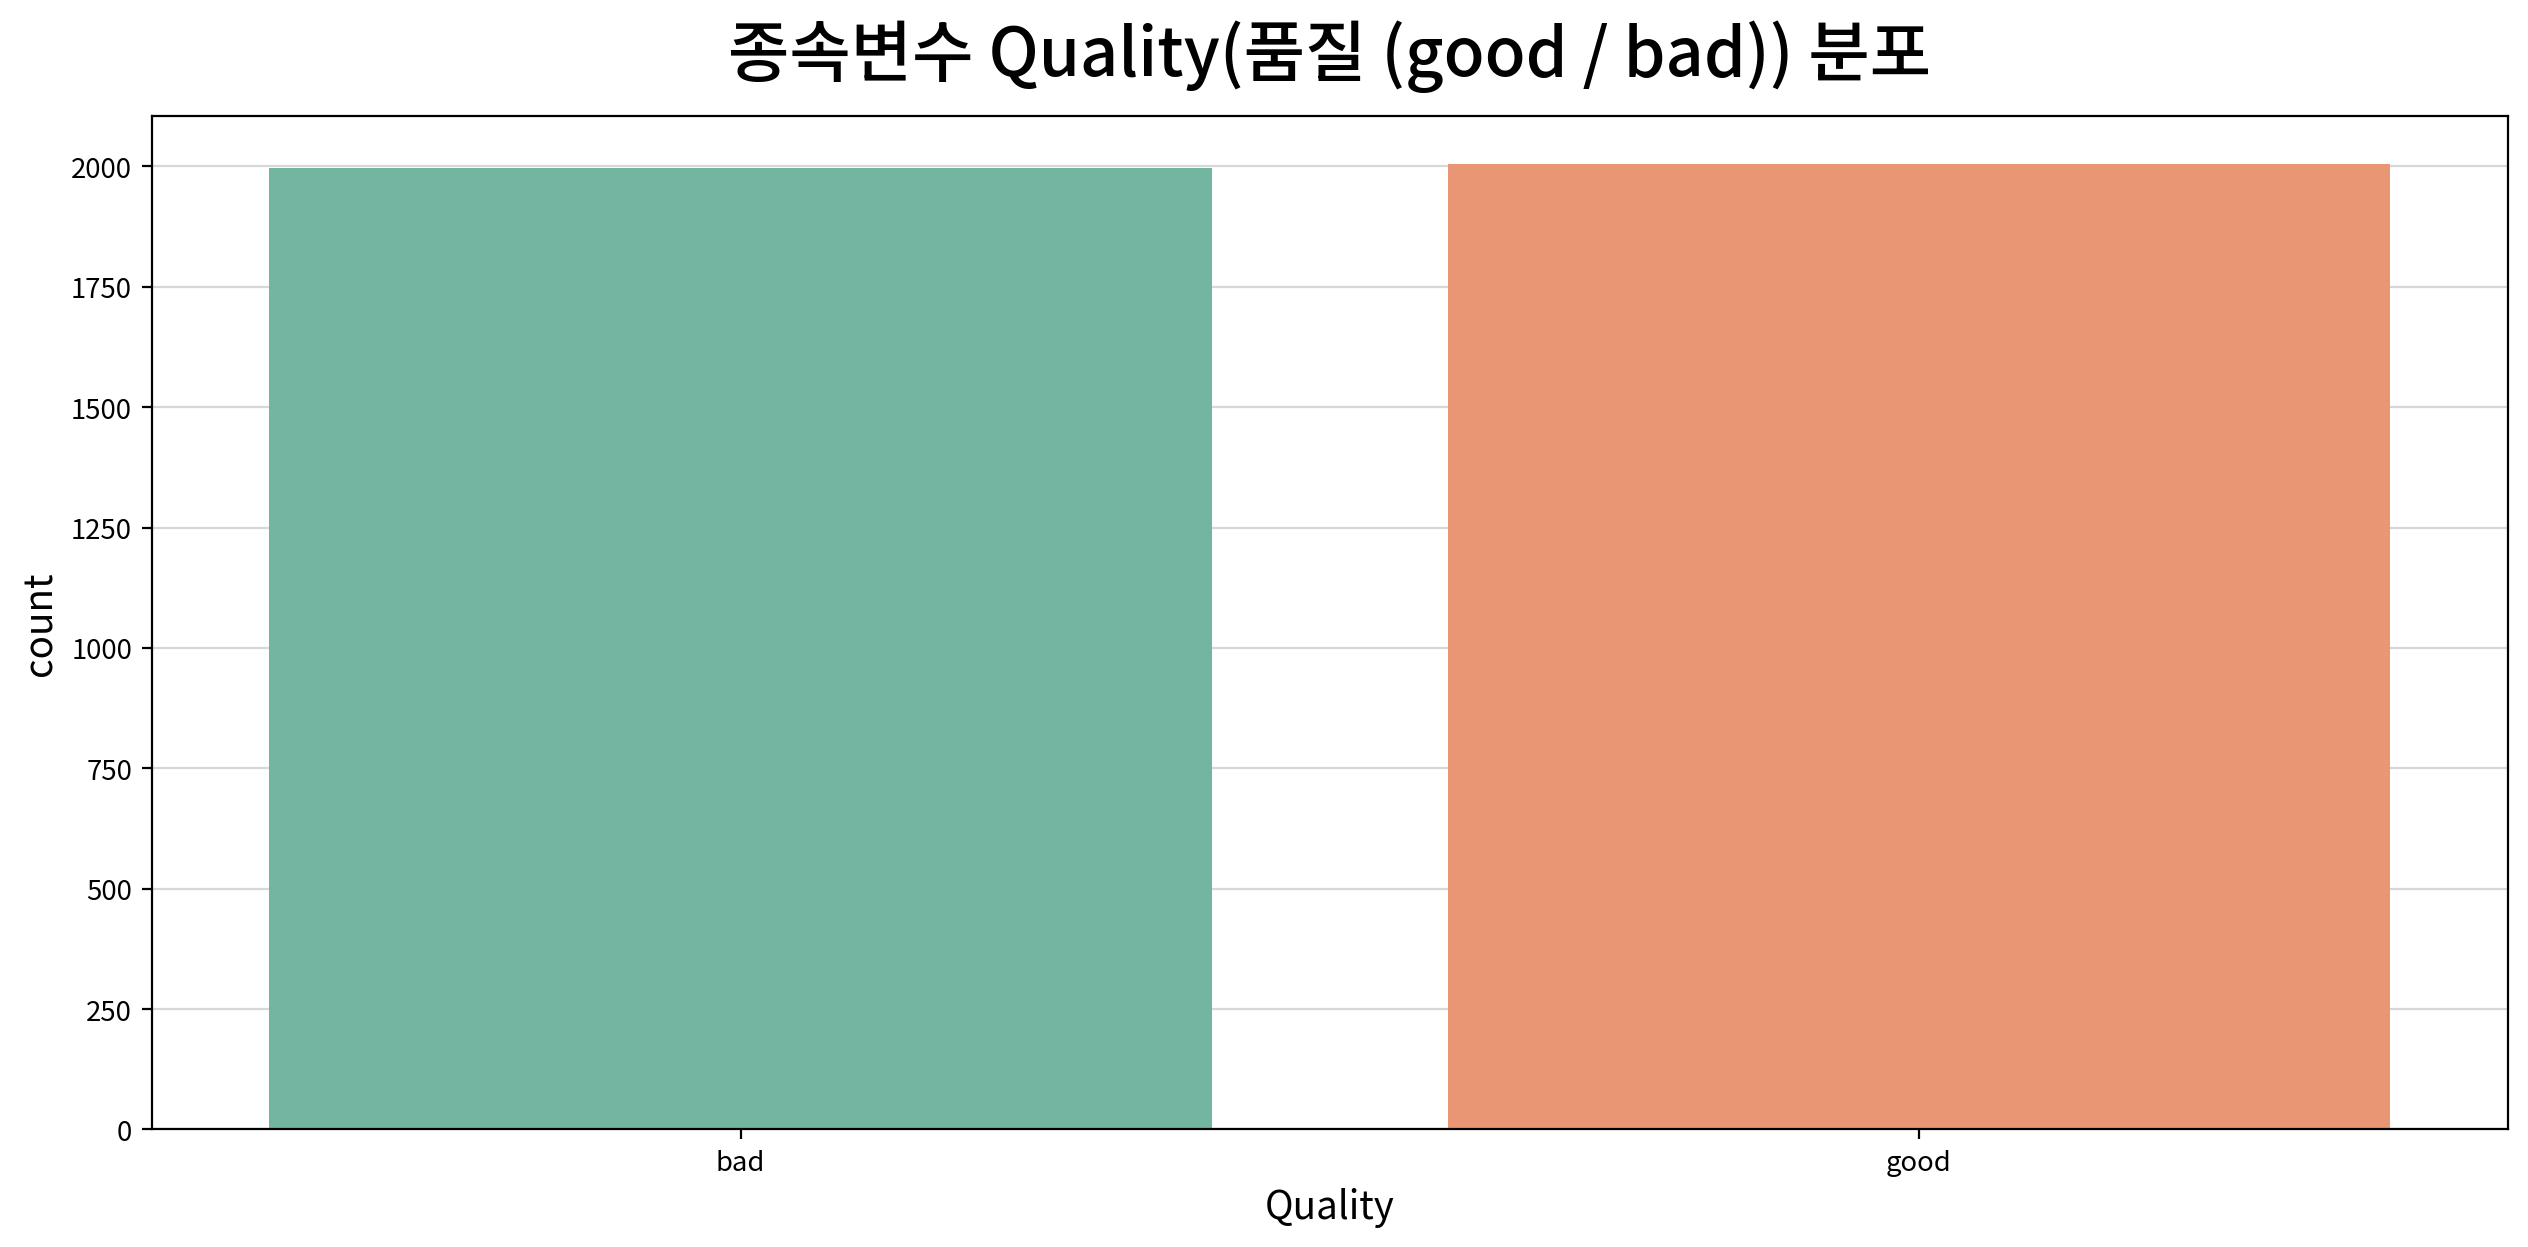

,count,unique,top,freq
Quality,4000,2,good,2004


,빈도,비율
Quality,,
good,2004,0.501
bad,1996,0.499


In [13]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette="Set2",
                  title=f"종속변수 {target}({column_means[target]}) 분포")

# 명목형 기술통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq = df[target].value_counts().rename("빈도").to_frame()
# value_counts(normalize=True)
# --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
freq["비율"] = df[target].value_counts(normalize=True)
display(freq)

##### 품질 라벨 분포

good 2,004건(50.1%), bad 1,996건(49.9%)으로 클래스 비율이 거의 같다. 항상 good으로 분류하는 단순 기준의 정확도는 50.1%다. 이는 모든 모델의 수학적 성능 하한이 아니며, 최종 평가는 정밀도·재현율·F1·ROC-AUC와 오분류 비용을 함께 살펴본다.

#### 2. 연속형 독립변수에 대한 단변량 분석

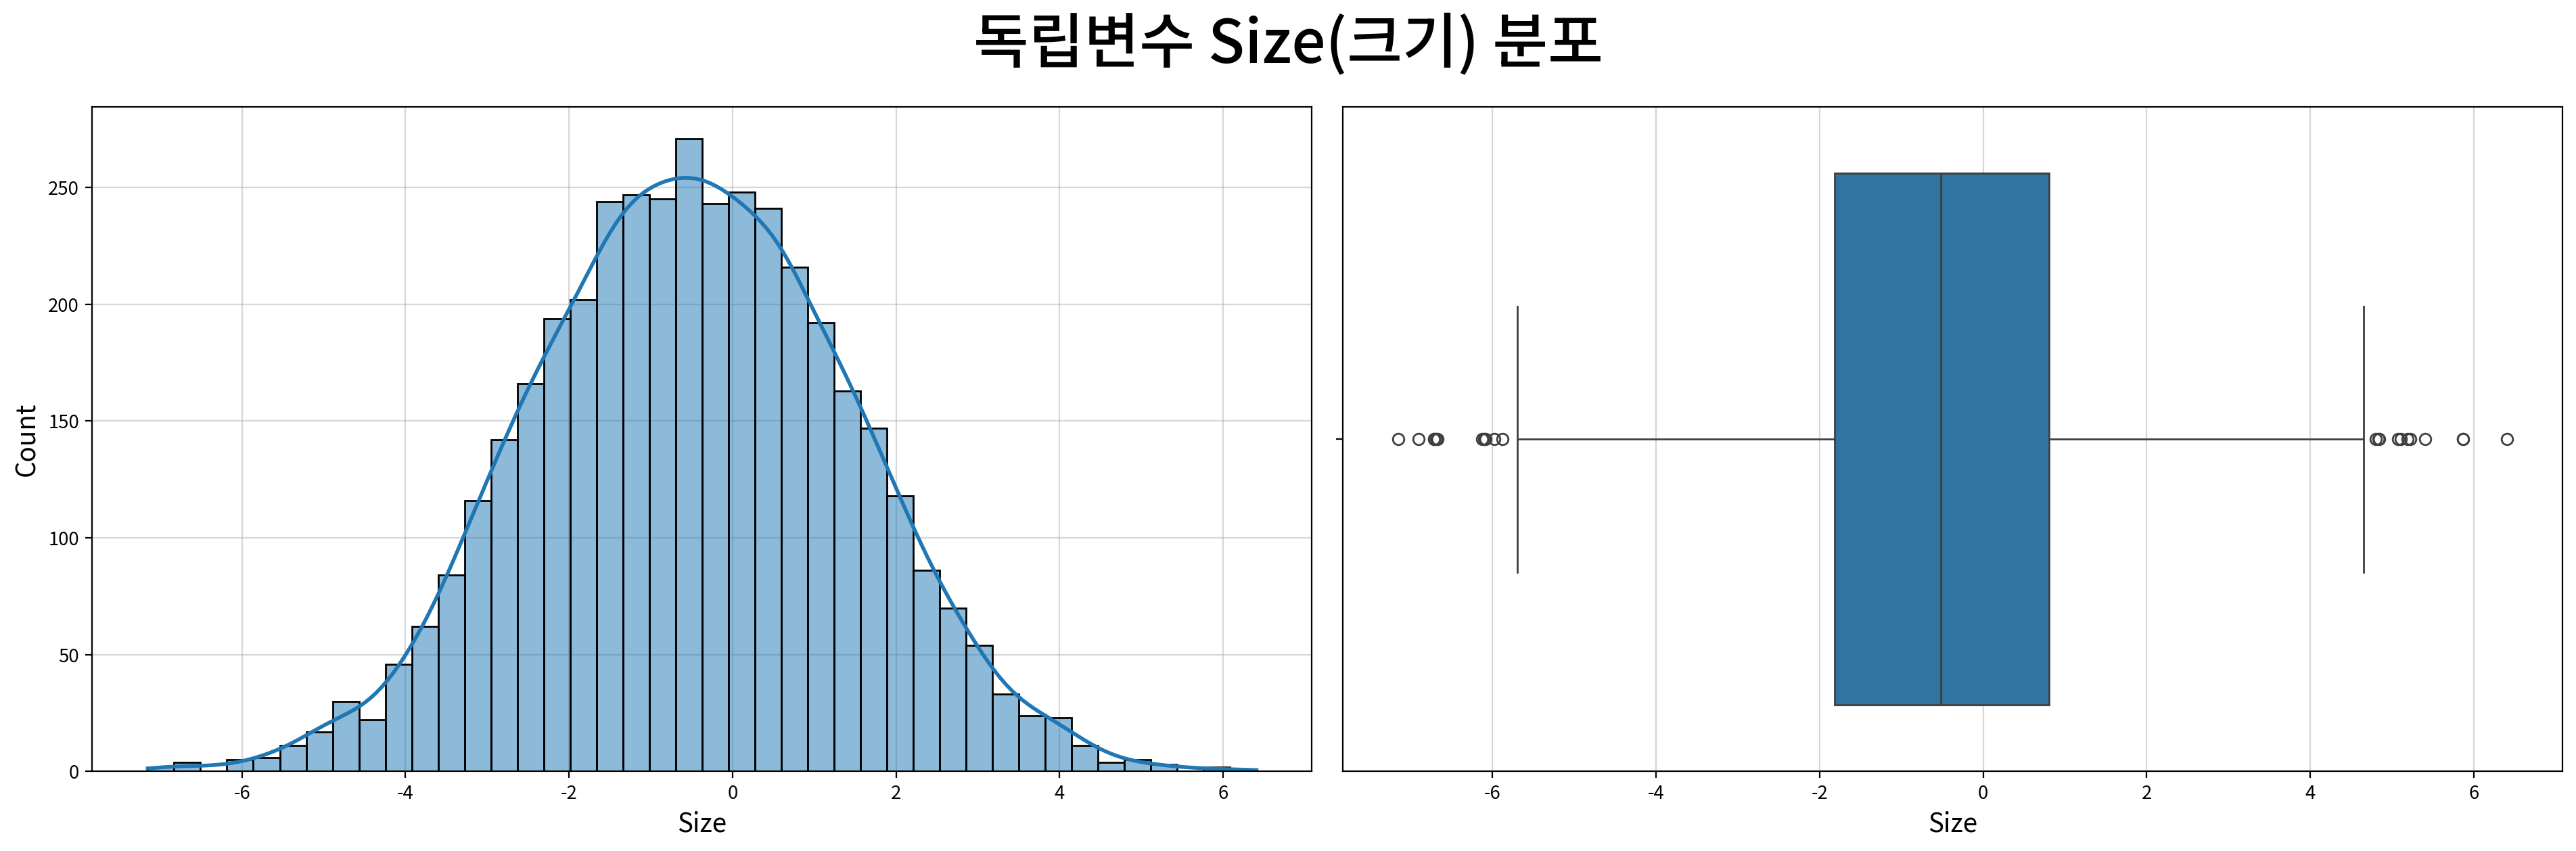

,Size
count,4000.000
mean,-0.503
std,1.928
min,-7.152
25%,-1.817
50%,-0.514
75%,0.806
max,6.406
rel_diff,-0.021
rdiff_flag,similar


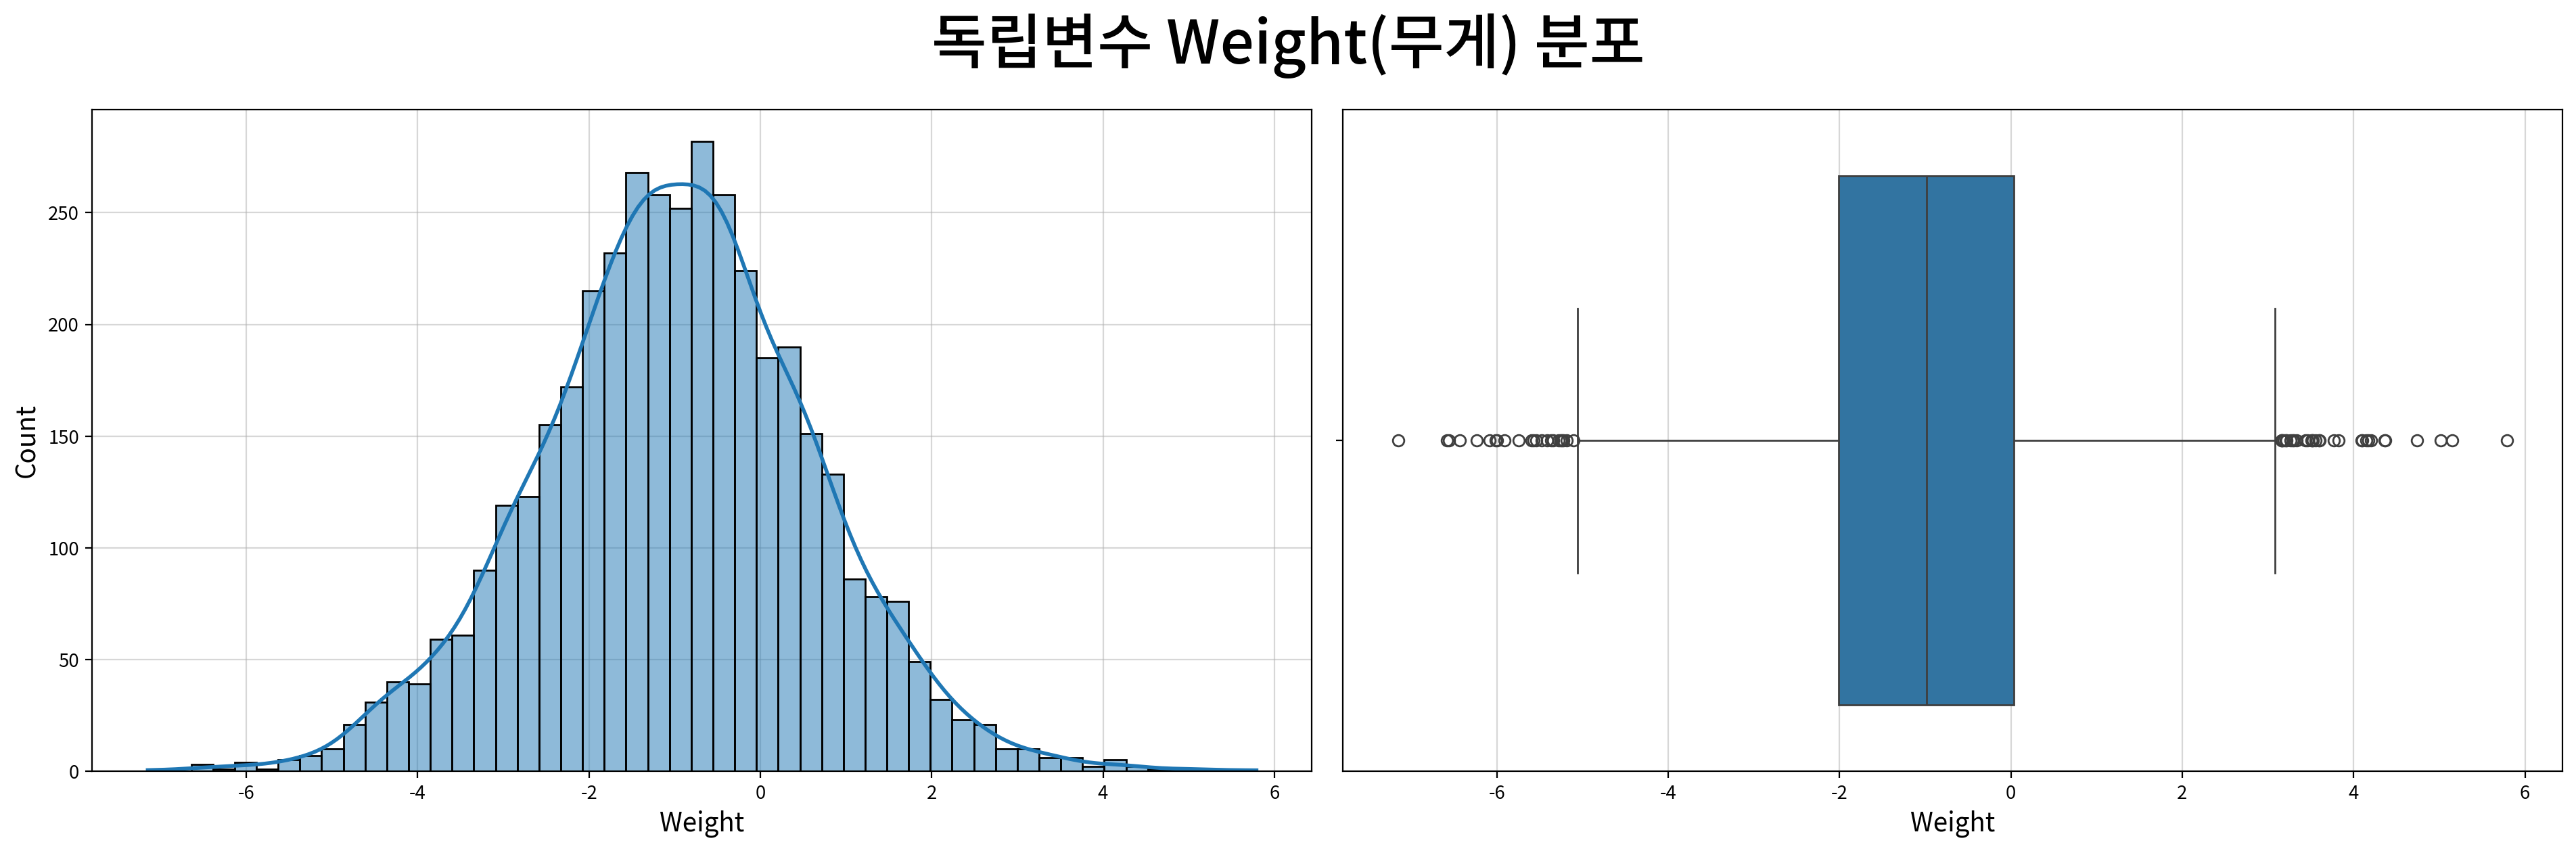

,Weight
count,4000.000
mean,-0.990
std,1.603
min,-7.150
25%,-2.012
50%,-0.985
75%,0.031
max,5.791
rel_diff,-0.005
rdiff_flag,similar


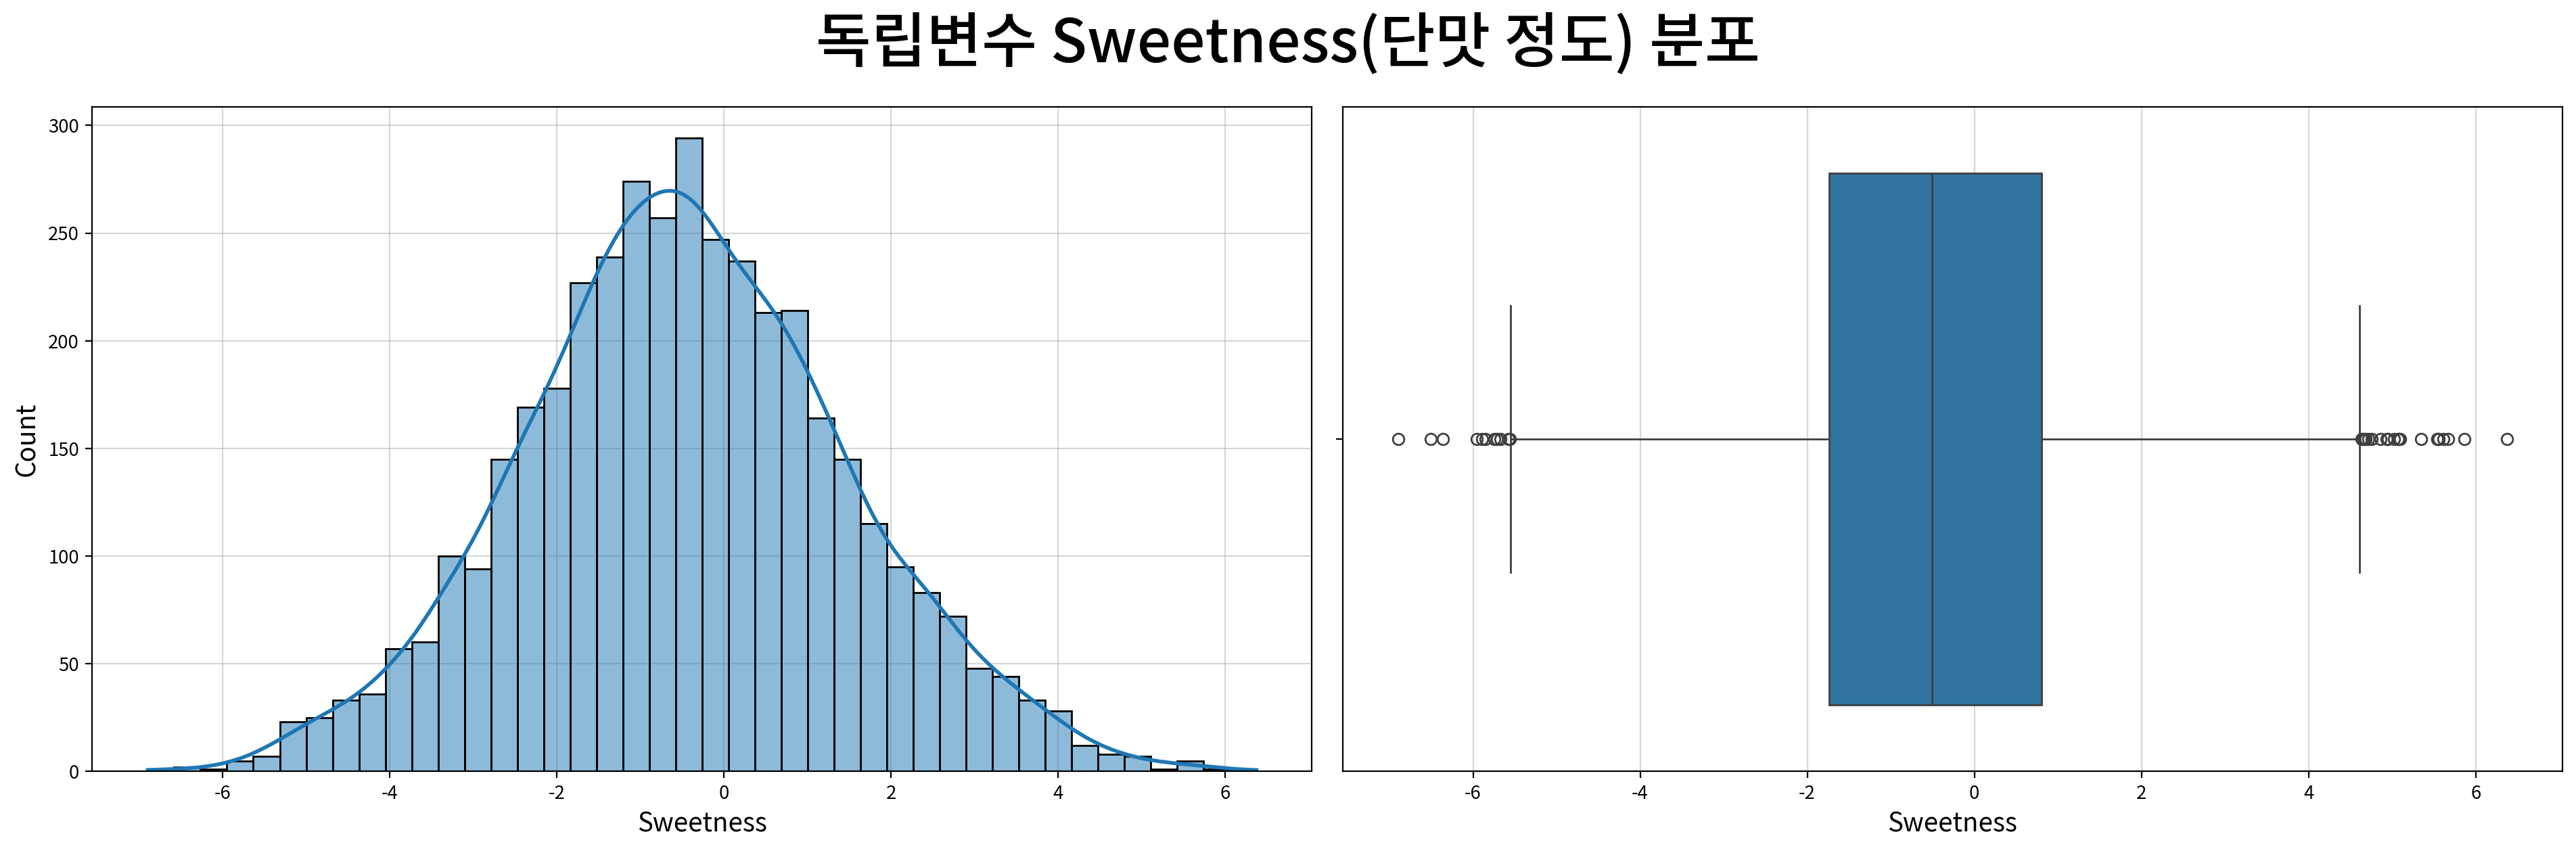

,Sweetness
count,4000.000
mean,-0.470
std,1.943
min,-6.894
25%,-1.738
50%,-0.505
75%,0.802
max,6.375
rel_diff,-0.068
rdiff_flag,similar


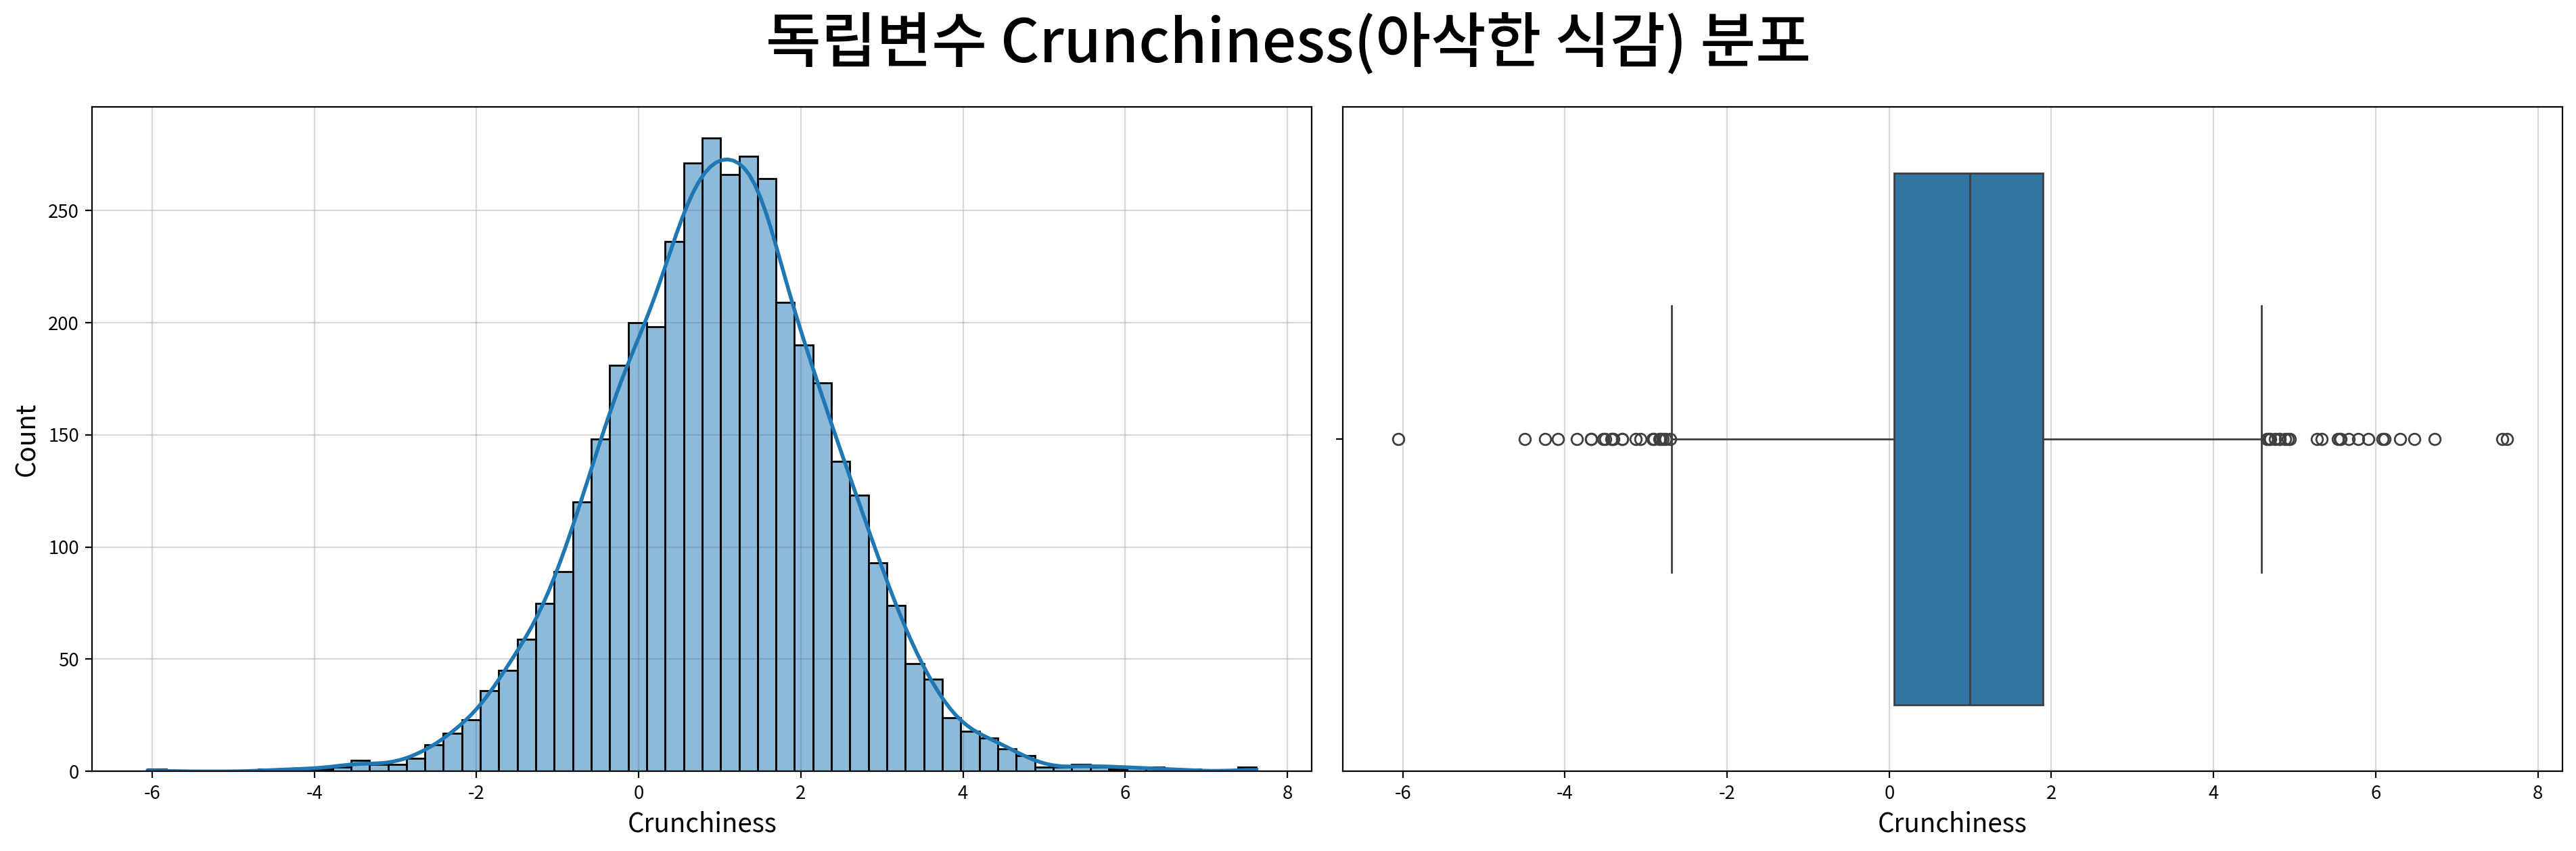

,Crunchiness
count,4000.000
mean,0.985
std,1.403
min,-6.055
25%,0.063
50%,0.998
75%,1.894
max,7.620
rel_diff,0.013
rdiff_flag,similar


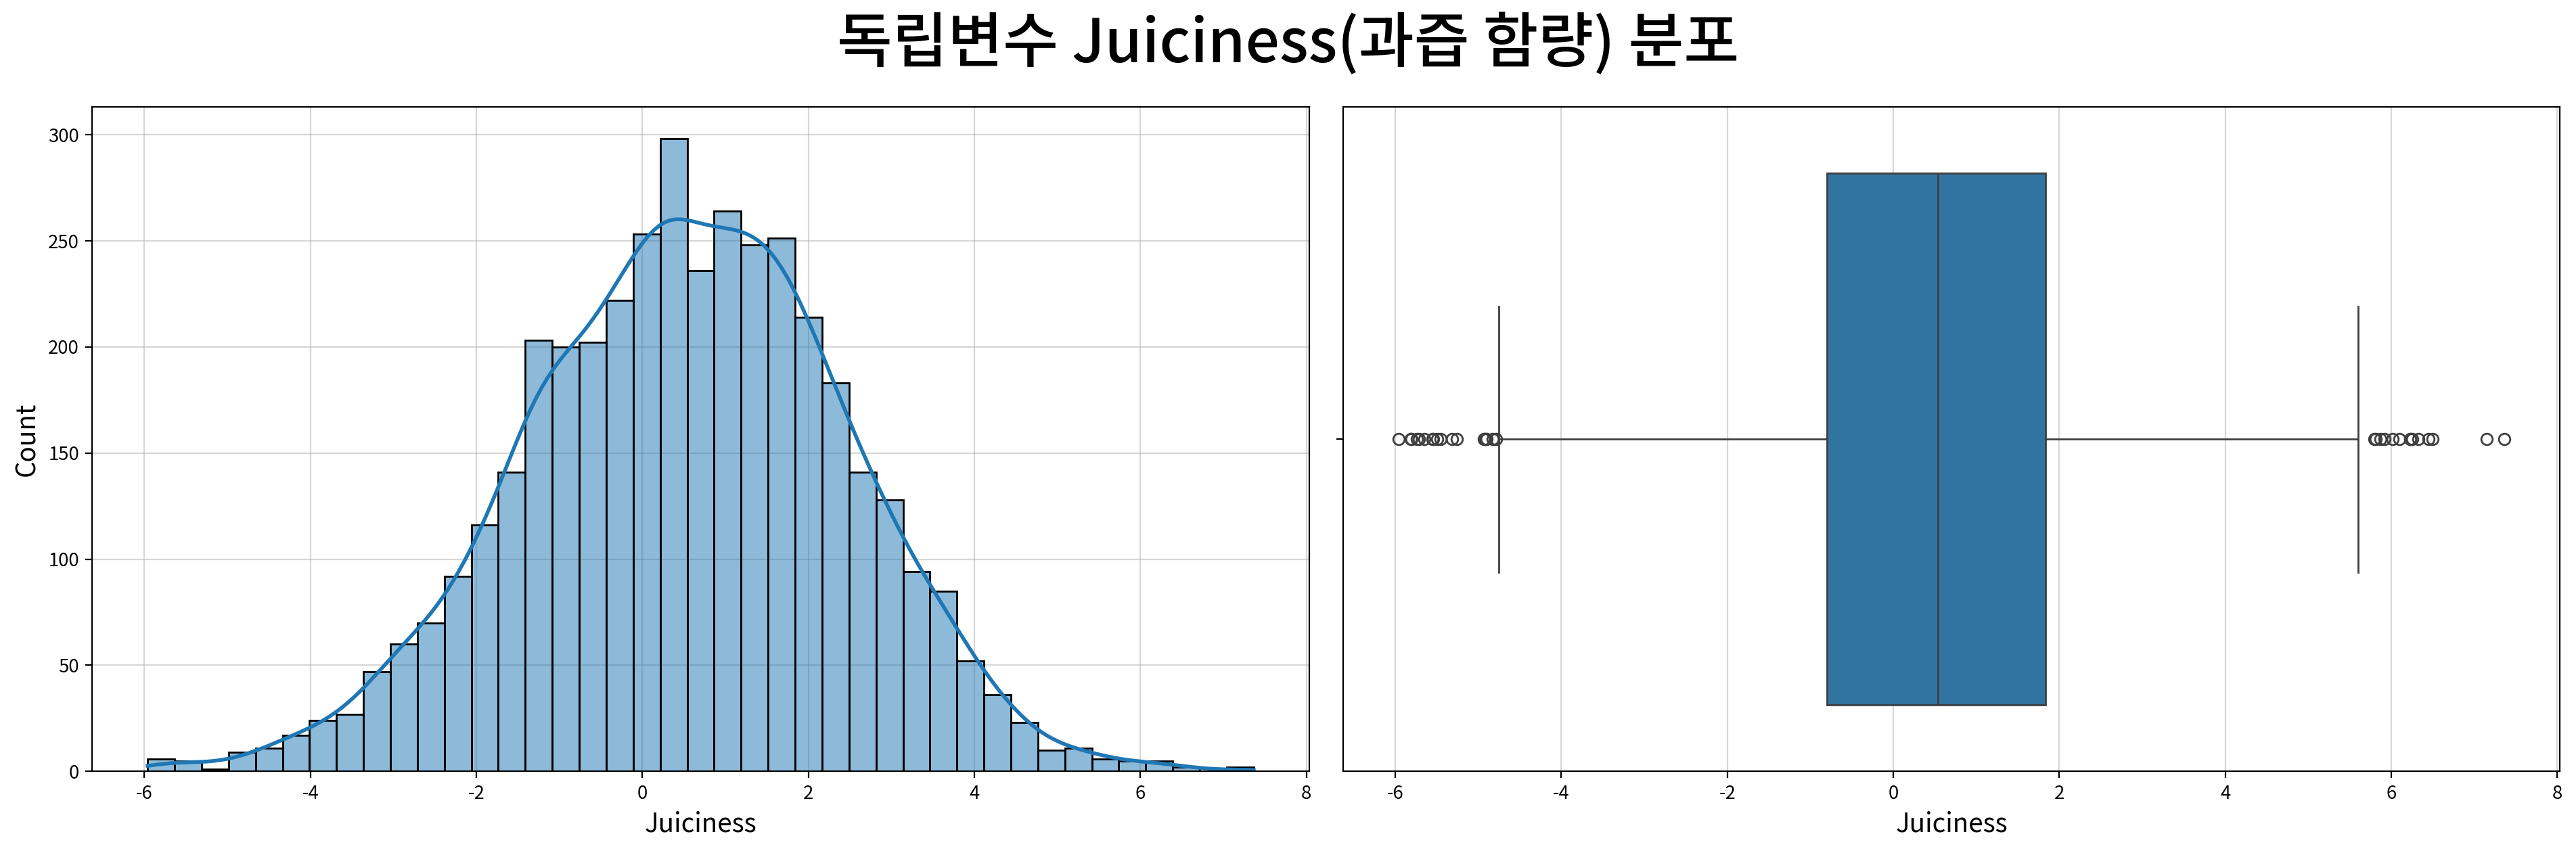

,Juiciness
count,4000.000
mean,0.512
std,1.930
min,-5.962
25%,-0.801
50%,0.534
75%,1.836
max,7.364
rel_diff,0.041
rdiff_flag,similar


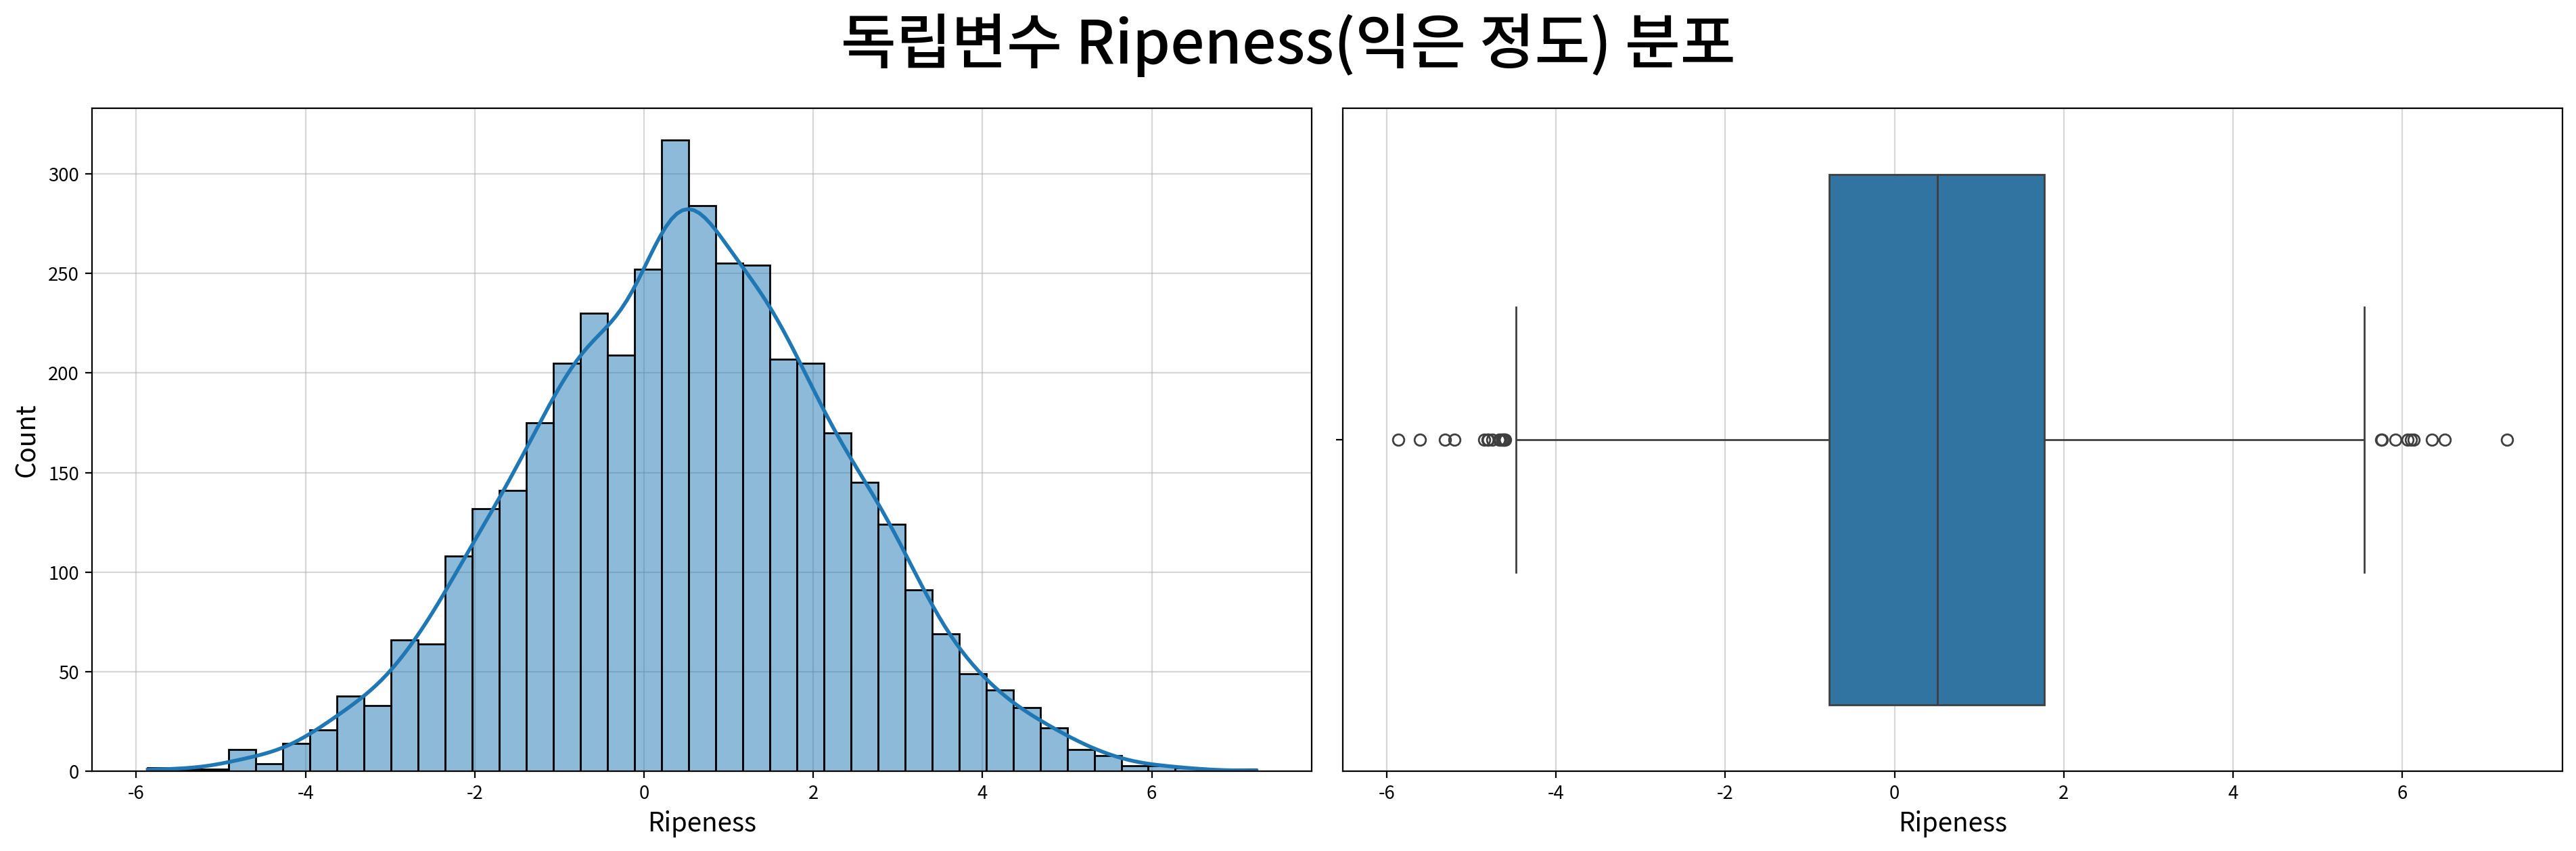

,Ripeness
count,4000.000
mean,0.498
std,1.874
min,-5.865
25%,-0.772
50%,0.503
75%,1.766
max,7.238
rel_diff,0.010
rdiff_flag,similar


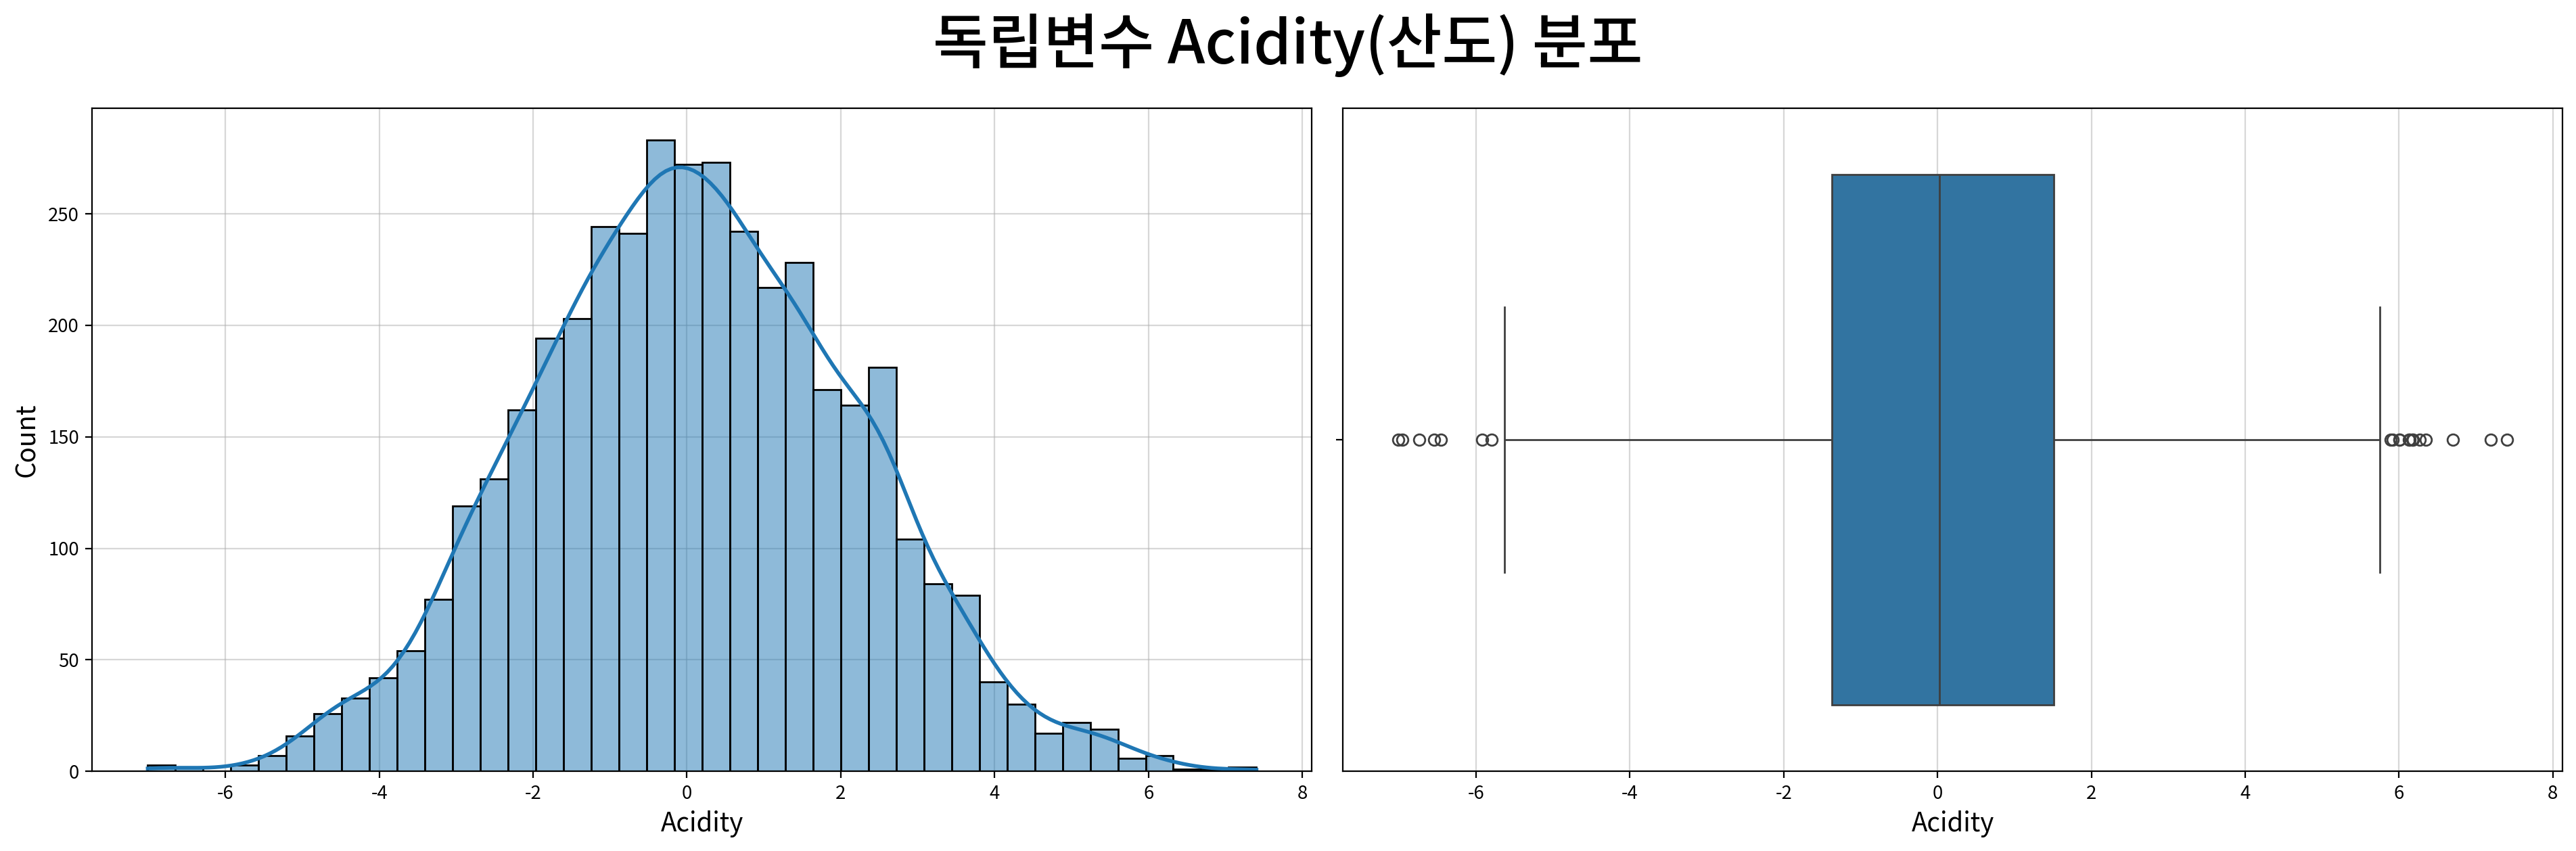

,Acidity
count,4000.000
mean,0.077
std,2.110
min,-7.011
25%,-1.377
50%,0.023
75%,1.510
max,7.405
rel_diff,2.400
rdiff_flag,large_diff


In [14]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

##### 💡 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 수 | 이상치 | 판단·조치 |
|---|---|---|---|---|
| `Size` | 대칭 (−0.002) | 단봉 | 22건 (0.55%) | 분포 왜도에 의한 로그변환 근거 작음 |
| `Weight` | 대칭 (+0.003) | 단봉 | 54건 (1.35%) | 분포 왜도에 의한 로그변환 근거 작음 |
| `Sweetness` | 대칭 (+0.084) | 단봉 | 32건 (0.8%) | 분포 왜도에 의한 로그변환 근거 작음 |
| `Crunchiness` | 대칭 (0.000) | 단봉 | 47건 (1.2%) | 분포 왜도에 의한 로그변환 근거 작음 |
| `Juiciness` | 대칭 (−0.113) | 단봉 | 32건 (0.8%) | 분포 왜도에 의한 로그변환 근거 작음 |
| `Ripeness` | 대칭 (−0.009) | 단봉 | 24건 (0.6%) | 분포 왜도에 의한 로그변환 근거 작음 |
| `Acidity` | 대칭 (+0.056) | 단봉 | 20건 (0.5%) | 분포 왜도에 의한 로그변환 근거 작음 |

### 이변량 분석

#### 1. 품질 집단 간 수치형 특성 비교

가정 점검에 따라 Welch t검정 또는 Mann–Whitney U 검정을 적용했다. t검정은 평균 차이, Mann–Whitney U는 순위 기반 분포 차이를 검토한다. 비유의성은 집단의 동등성이나 완전한 무관함을 뜻하지 않는다.

#### ▶︎ Size(크기) → Quality

statistic  p-value  significant       result
test                alternative                                               
Mann-Whitney U test two-sided   1433524.000    0.000         True  bad != good
                    less        1433524.000    0.000         True   bad < good
                    greater     1433524.000    1.000        False  bad <= good

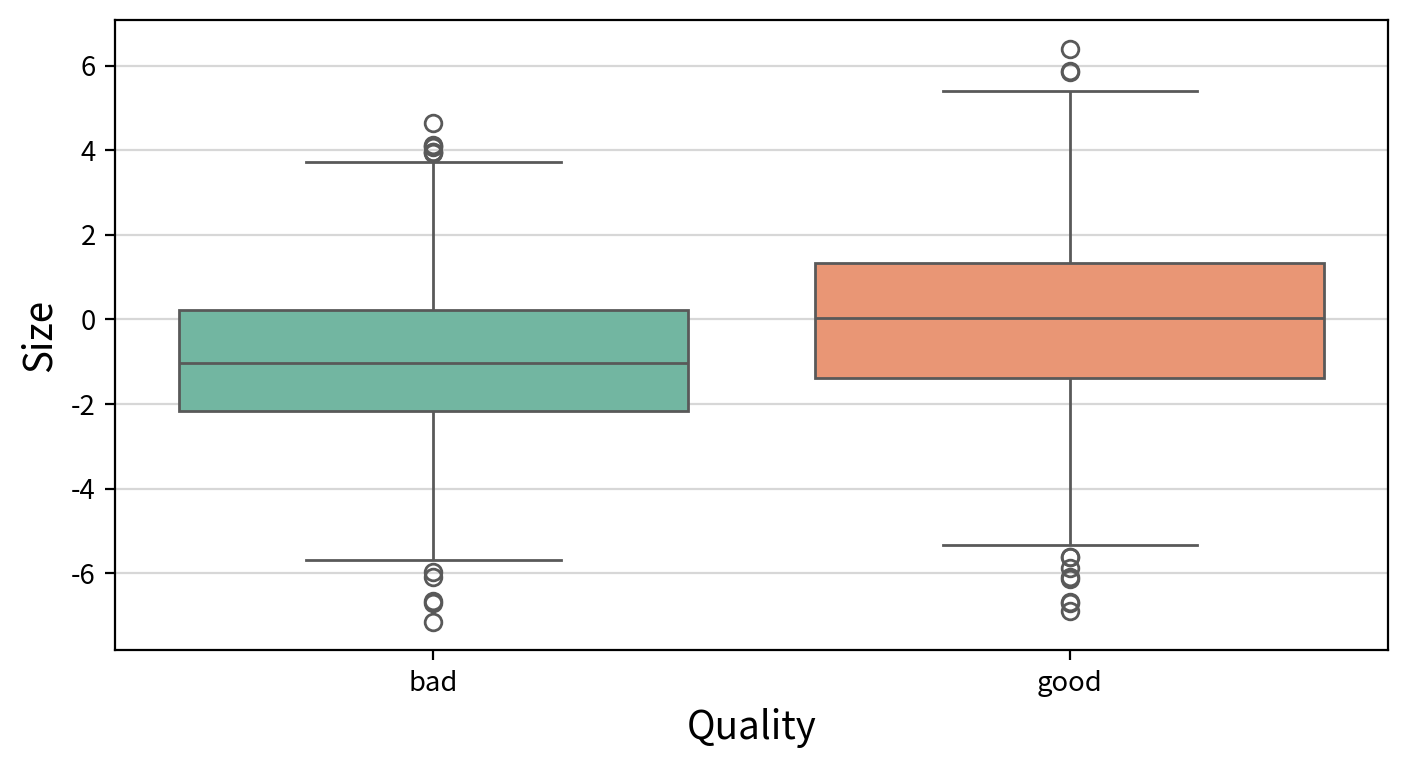

#### ▶︎ Weight(무게) → Quality

statistic  p-value  significant       result
test         alternative                                              
Welch t-test two-sided       -0.090    0.928        False   bad = good
             less            -0.090    0.464        False  bad >= good
             greater         -0.090    0.536        False  bad <= good

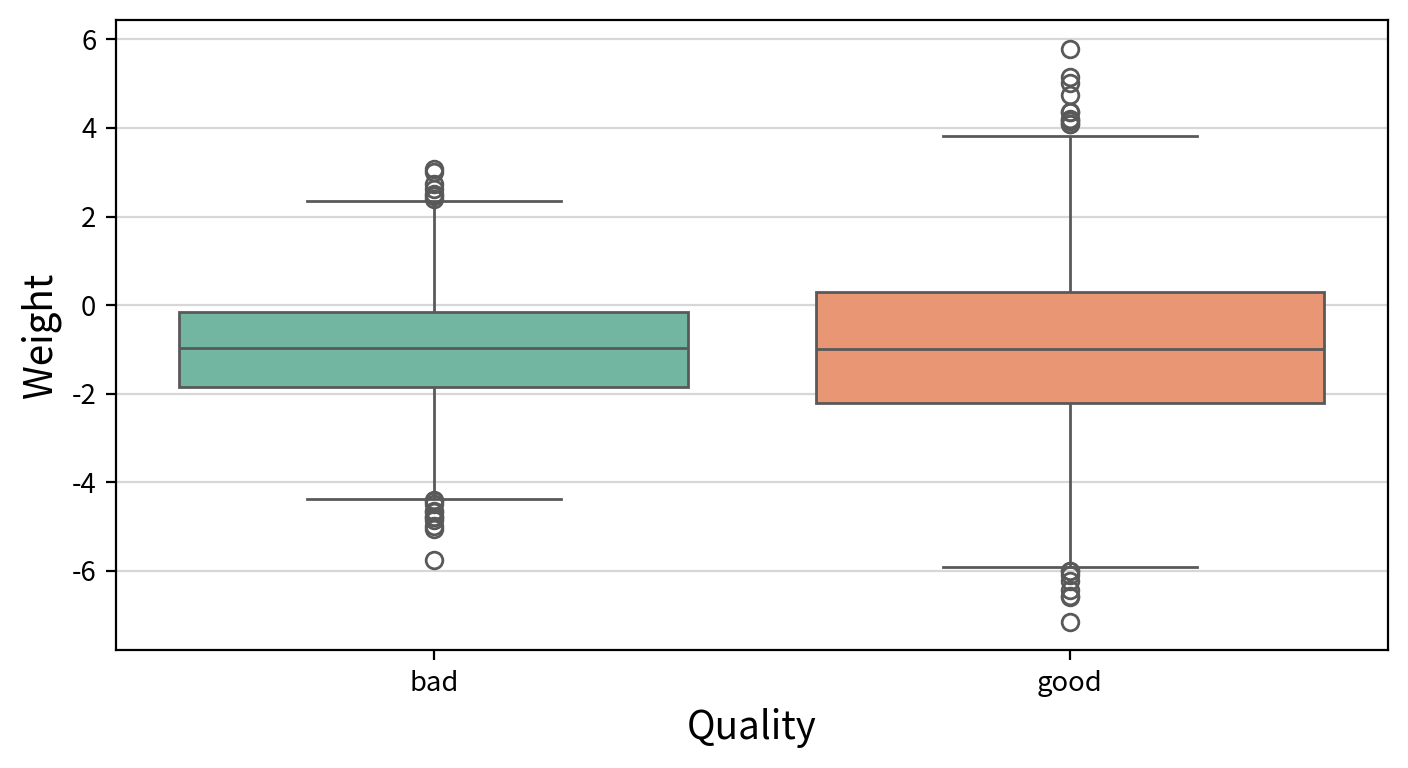

#### ▶︎ Sweetness(단맛 정도) → Quality

statistic  p-value  significant       result
test                alternative                                               
Mann-Whitney U test two-sided   1452149.000    0.000         True  bad != good
                    less        1452149.000    0.000         True   bad < good
                    greater     1452149.000    1.000        False  bad <= good

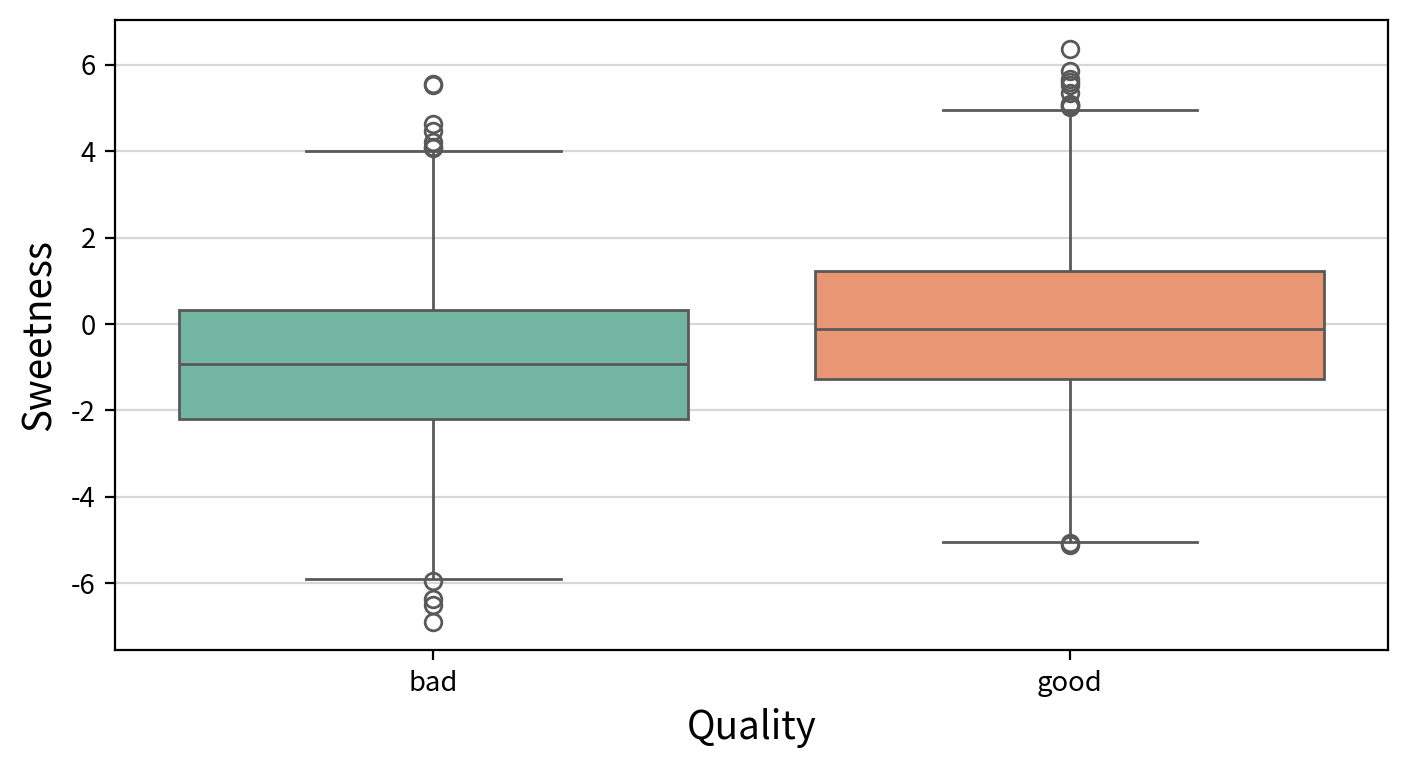

#### ▶︎ Crunchiness(아삭한 식감) → Quality

statistic  p-value  significant       result
test                alternative                                               
Mann-Whitney U test two-sided   1999316.000    0.985        False   bad = good
                    less        1999316.000    0.493        False  bad >= good
                    greater     1999316.000    0.507        False  bad <= good

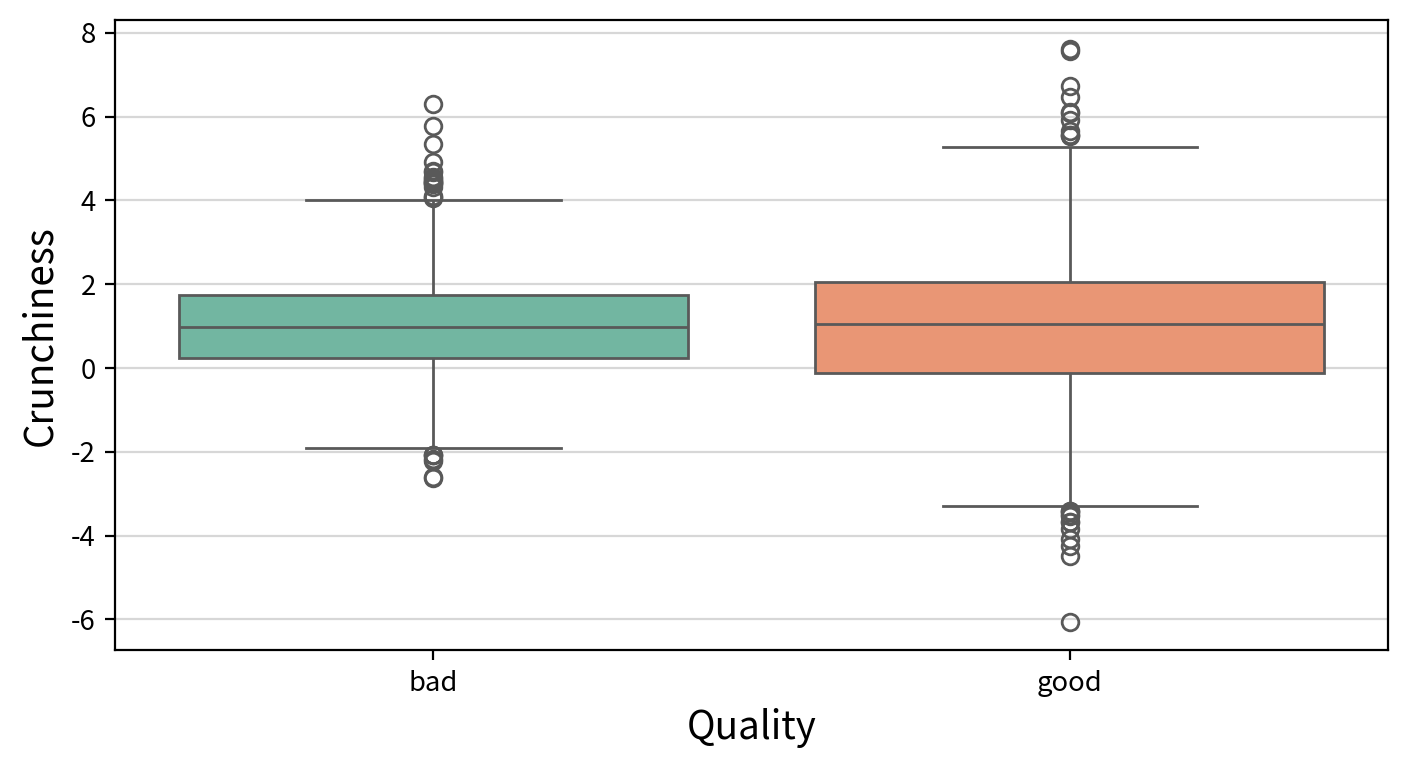

#### ▶︎ Juiciness(과즙 함량) → Quality

statistic  p-value  significant       result
test         alternative                                              
Welch t-test two-sided      -17.035    0.000         True  bad != good
             less           -17.035    0.000         True   bad < good
             greater        -17.035    1.000        False  bad <= good

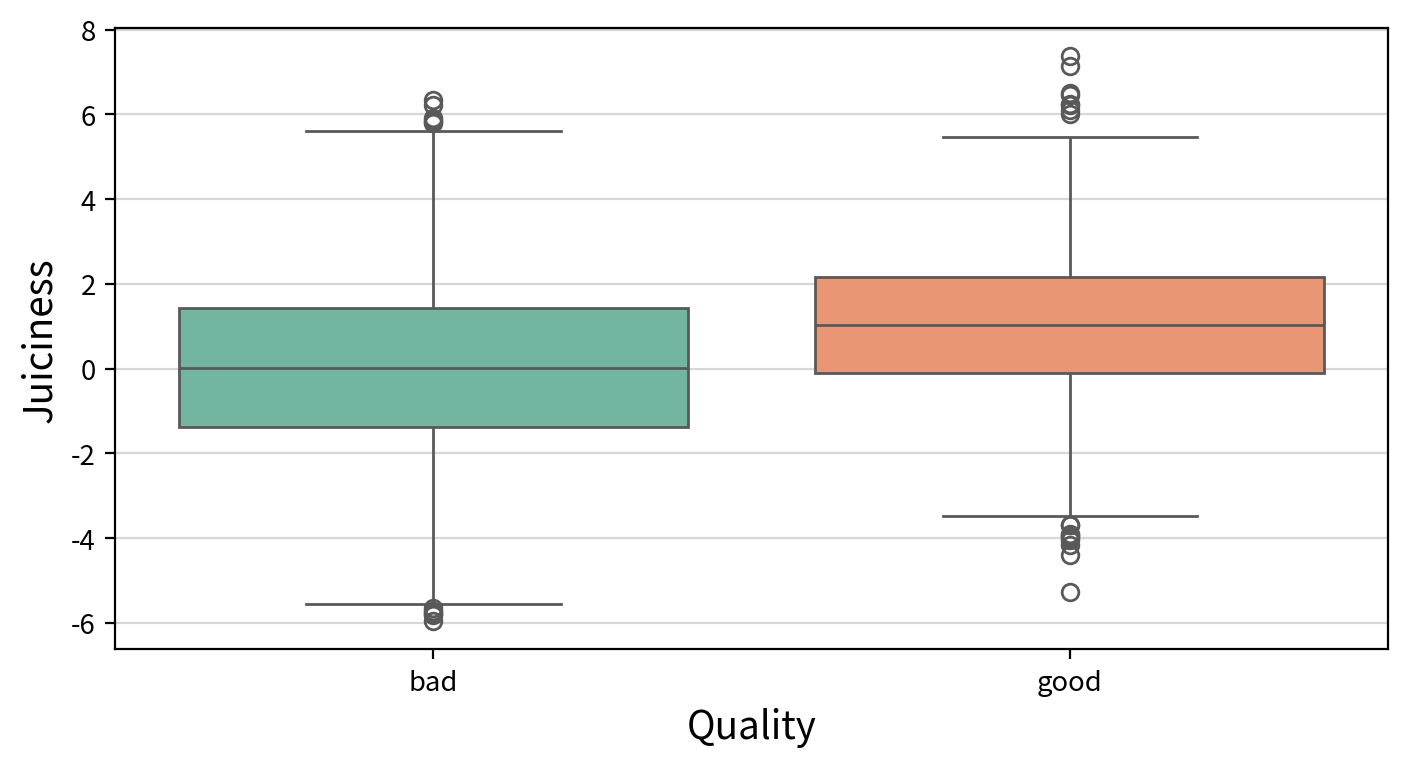

#### ▶︎ Ripeness(익은 정도) → Quality

statistic  p-value  significant       result
test         alternative                                              
Welch t-test two-sided       17.326    0.000         True  bad != good
             less            17.326    1.000        False  bad >= good
             greater         17.326    0.000         True   bad > good

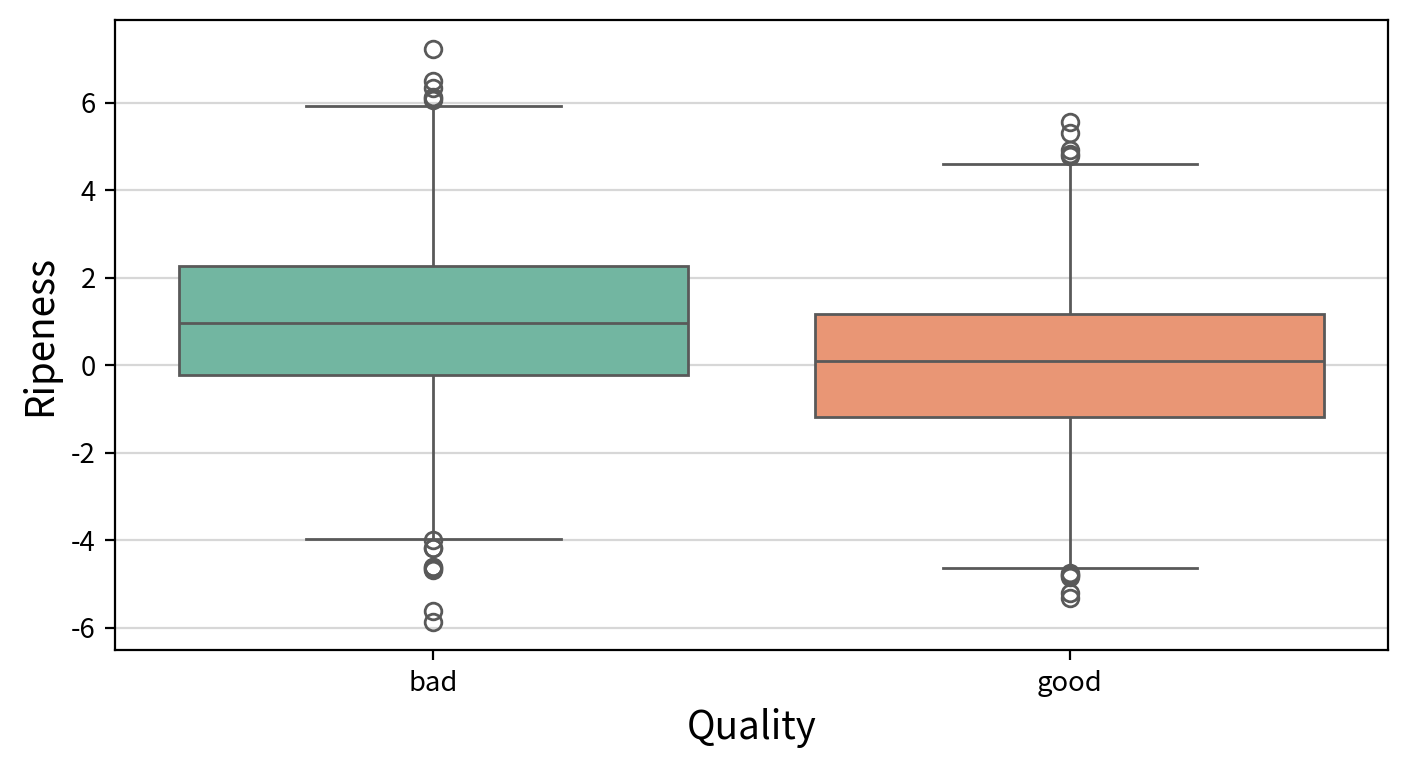

#### ▶︎ Acidity(산도) → Quality

statistic  p-value  significant       result
test                alternative                                               
Mann-Whitney U test two-sided   1990597.000    0.797        False   bad = good
                    less        1990597.000    0.399        False  bad >= good
                    greater     1990597.000    0.602        False  bad <= good

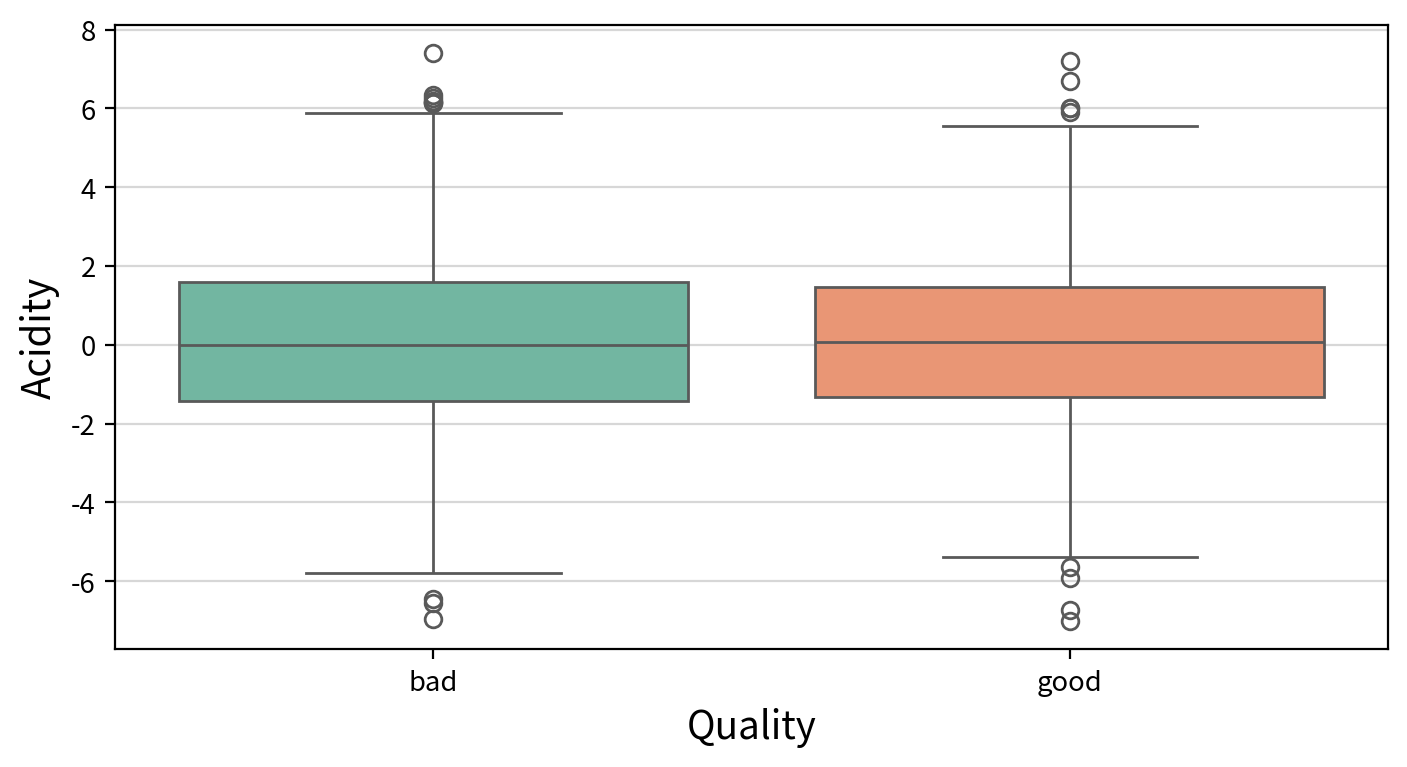

In [15]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # -> 선형회귀 때와 hue/values 가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df,
                group1=wide_df.columns[0], group2=wide_df.columns[1], plot=False))

    # 시각화: 종속변수 집단별 분포 비교
    my_plot.boxplot(data=df, x=target, y=f, hue=target, palette="Set2",
                    width=720, height=400)

##### 💡 인사이트

| 변수 | 검정 방법 | 유의확률 | 집단 차이 | 방향 | 단독 채택 |
|---|---|---|---|---|---|
| `Size` | Mann-Whitney U | < 0.001 | 유의 | `bad` < `good` | ✅ |
| `Sweetness` | Mann-Whitney U | < 0.001 | 유의 | `bad` < `good` | ✅ |
| `Ripeness` | Welch t검정 | < 0.001 | 유의 | `bad` > `good` | ✅ |
| `Juiciness` | Welch t검정 | < 0.001 | 유의 | `bad` < `good` | ✅ |
| `Weight` | Welch t검정 | 0.928 | **유의한 차이를 발견하지 못함** | — | 🟡 보류 |
| `Acidity` | Mann-Whitney U | 0.797 | **유의한 차이를 발견하지 못함** | — | 🟡 보류 |
| `Crunchiness` | Mann-Whitney U | 0.985 | **유의한 차이를 발견하지 못함** | — | 🟡 보류 |

#### 2. 교차분석 (x: 명목형 독립변수 → y: 명목형 종속변수)

- 명목형 독립변수가 있을 경우 카이제곱 독립성 검정을 수행한다.
  - 명목형 독립변수가 없을 경우 출력 결과가 없을 수 있다.

In [16]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=False))

##### 💡 인사이트

> 이 데이터셋에는 **명목형 독립변수가 없으므로** 해당 없음. (출력 결과 없음)

### 다변량 분석

#### 1. 독립변수간 상관 분석

- 연속형 독립변수끼리는 종속변수가 명목형이어도 상관분석을 그대로 쓸 수 있다.
- 목적이 다르다. 여기서는 **설명력 확인이 아니라 다중공선성 점검**이다.

In [17]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
Size,1.000,-0.144,-0.325,0.172,-0.032,-0.155,0.210
Weight,-0.144,1.000,-0.120,-0.087,-0.091,-0.244,0.030
Sweetness,-0.325,-0.120,1.000,-0.017,0.098,-0.255,0.072
Crunchiness,0.172,-0.087,-0.017,1.000,-0.236,-0.184,0.074
Juiciness,-0.032,-0.091,0.098,-0.236,1.000,-0.124,0.231
Ripeness,-0.155,-0.244,-0.255,-0.184,-0.124,1.000,-0.195
Acidity,0.210,0.030,0.072,0.074,0.231,-0.195,1.000


,max-y,max-coef,count,columns
x,,,,
Size,Sweetness,-0.325,0,-
Sweetness,Size,-0.325,0,-
Ripeness,Sweetness,-0.255,0,-
Weight,Ripeness,-0.244,0,-
Crunchiness,Juiciness,-0.236,0,-
Juiciness,Crunchiness,-0.236,0,-
Acidity,Juiciness,0.231,0,-


##### 독립변수 간 관계

상관 요약에는 |r| ≥ 0.7인 쌍이 없었다. 이는 강한 쌍별 상관 신호가 없다는 뜻이다. 다변량 공선성이나 계수 안정성까지 보장하지 않으므로 뒤 모형의 VIF를 함께 확인한다.

### 최종 변수 선택

식별자 A_id만 제외하고 Size·Weight·Sweetness·Crunchiness·Juiciness·Ripeness·Acidity 7개를 모두 모델에 투입한다. 집단 비교에서 Size·Sweetness·Juiciness·Ripeness는 유의한 차이를 보였고, Weight·Acidity·Crunchiness는 유의한 차이를 발견하지 못했다.

단독 검정의 비유의성이 다변량·비선형 관계까지 부정하지는 않는다. 여기서 세 변수를 미리 삭제하지 않고, 원본의 로짓 선형성 진단과 전처리·후진소거 체크포인트 비교로 이어간다.

<a id="stage-2"></a>

## 2. 로지스틱 회귀·가정 진단·모형 비교·해석

> 저장된 실행 결과와 대조하여 수치·해석을 확정했다.


### 로지스틱 회귀 기준선 모형

#### 1. 종속변수 라벨링

- 로지스틱 회귀의 종속변수는 **0/1의 정수**여야 한다. 문자열 `good`/`bad`를 숫자로 바꾼다.
- `my_prep.labeling()`은 **알파벳 순서**로 0부터 매긴다. → `bad = 0`, `good = 1`
- 즉 이 모형이 예측하는 것은 **P(Quality = good)** 이고,
  뒤에 나오는 오즈비는 모두 **"사과가 `good`일 오즈"** 에 대한 값이다.

In [18]:
base = my_prep.labeling(df, columns=[target])
base.head()

Quality (2종): bad=0,good=1


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,1
1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,1
2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,0
3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,1
4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,1


#### 2. 기준선 모형 적합

In [19]:
fit_base = my_logit.fit_model(base, y=target)
my_logit.report_variables(fit_base, base)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95 하한,OR 95 상한,공차,VIF
0,Quality,Size,0.649,1.252,0.028,22.993,0.000,1.915,1.811,2.024,0.708,1.413
1,Quality,Sweetness,0.569,1.105,0.027,20.938,0.000,1.766,1.675,1.863,0.677,1.477
2,Quality,Juiciness,0.442,0.854,0.024,18.242,0.000,1.556,1.484,1.632,0.820,1.219
3,Quality,Acidity,-0.294,-0.621,0.021,-13.697,0.000,0.745,0.714,0.777,0.853,1.172
4,Quality,Weight,0.267,0.427,0.028,9.399,0.000,1.306,1.235,1.380,0.742,1.348
5,Quality,Ripeness,-0.127,-0.238,0.025,-5.132,0.000,0.881,0.839,0.925,0.677,1.478
6,Quality,Crunchiness,0.035,0.049,0.030,1.143,0.253,1.035,0.976,1.098,0.821,1.218


##### 단독 비교와 조건부 관계

집단 비교에서 Weight(p≈0.928), Acidity(p≈0.797)는 유의한 차이를 발견하지 못했지만, 다른 변수를 포함한 기준선 로지스틱 회귀에서는 유의했다(p<0.001). Crunchiness는 기준선에서도 p≈0.253이었다. 이 결과는 단독 검정만으로 변수를 제외하지 않을 근거다. 다만 두 검정은 질문이 다르므로 유의성 변화만으로 억제효과의 발생 원인을 확정하지 않는다.

기준선 Acidity OR≈0.745는 다른 포함 특성이 같을 때 지표 1 증가에 따른 good 오즈의 약 25.5% 감소라는 모형상 관계다. 확률 25.5%p 감소나 인과효과가 아니며, 뒤 제곱항 모형에는 이 직선 해석을 그대로 적용하지 않는다.

### 가정 검정

#### 1. 기준선 모형의 로짓 선형성 검정 (Box-Tidwell)

- 독립변수 x에 `x × ln(x)` 항을 추가해 **그 항이 유의한지** 본다.
  - 유의하면(p < 0.05) 로짓 선형성 위반 신호로 해석 → 변환·제곱항·구간화 등 모형식 검토의 근거로 삼는다.

In [20]:
my_logit.test_linear(fit_base, base)

,z,p-value,linearity,위치이동,result
독립변수,,,,,
Size,4.323,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Weight,11.161,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Sweetness,0.605,0.545,True,True,귀무가설 기각 못함 → 로짓 선형성 위배 근거 없음
Crunchiness,9.851,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Juiciness,-8.075,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)
Ripeness,-1.047,0.295,True,True,귀무가설 기각 못함 → 로짓 선형성 위배 근거 없음
Acidity,-5.553,0.000,False,True,대립가설 채택 → 로짓 선형성 위배(변환 필요)


> Box–Tidwell 결과에서 Size·Weight·Crunchiness·Juiciness·Acidity는 로짓 선형성 위반 신호를 보였다. Sweetness(p≈0.545)와 Ripeness(p≈0.295)의 비기각은 선형성을 입증하는 것이 아니다. 음수가 있는 변수는 로그 정의역을 맞추어 검정하며, 뒤 반복 진단 결과와 실제 변환 목록을 확인한다.

#### 2. 진단 → 처방 → 검증 → 재진단 루프

In [21]:
fit_fixed = my_logit.fix_linear(base, y=target)

[라운드 1] 위배 5종 → 'Weight' 처방 (z = 11.1613)
    → 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 0.0000e+00, AIC = 3962.44
[라운드 2] 위배 5종 → 'Crunchiness' 처방 (z = 9.0855)
    → 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 0.0000e+00, AIC = 3867.27
[라운드 3] 위배 3종 → 'Juiciness' 처방 (z = -10.5276)
    → 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 0.0000e+00, AIC = 3744.33
[라운드 4] 위배 3종 → 'Acidity' 처방 (z = -7.4836)
    → 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 3.2307e-14, AIC = 3688.74
[라운드 5] 위배 2종 → 'Ripeness' 처방 (z = -3.0869)
    → 제곱항 채택 (제곱항 p = 0.0023), 우도비 p = 2.1255e-03, AIC = 3681.30
[라운드 6] 위배 1종 → 'Size' 처방 (z = 2.9542)
    → 제곱항 채택 (제곱항 p = 0.0025), 우도비 p = 2.2468e-03, AIC = 3673.97
[라운드 7] 위배 변수 없음 → 루프 종료



,변수,처방,제곱항 p,검증 p,AIC,채택
라운드,,,,,,
1,Weight,제곱항,0.000,0.000,3962.440,True
2,Crunchiness,제곱항,0.000,0.000,3867.270,True
3,Juiciness,제곱항,0.000,0.000,3744.330,True
4,Acidity,제곱항,0.000,0.000,3688.740,True
5,Ripeness,제곱항,0.002,0.002,3681.300,True
6,Size,제곱항,0.003,0.002,3673.970,True


##### 반복 진단의 의미

실행 결과는 Weight → Crunchiness → Juiciness → Acidity → Ripeness → Size 순서의 처방 뒤 추가 위반 신호가 사라졌고 Sweetness는 원래 항으로 남았다. 한 변수의 모형식을 바꾸면 다른 변수의 진단도 달라질 수 있으므로 재진단을 반복한다.

Crunchiness는 단독 집단 비교와 직선항 기준선에서는 비유의했으나 제곱항 모형에서는 곡선 관계가 드러났다. 평균 또는 직선항만으로 비선형 관계를 배제하면 안 된다는 사례다. 비기각으로 종료한 사실만으로 참 모형을 찾았다고 단정하지 않는다.

#### 3. 계층 원칙

제곱항을 포함하면 그 짝인 1차항이 비유의하더라도 함께 유지한다. 중심화한 1차항을 제거하면 곡선의 꼭짓점을 중심값에 고정하는 제약이 생기기 때문이다. 아래 체크포인트 비교에서 5번이 제거한 Crunchiness_c와 4번의 항 구성을 확인하고 최종 모형을 선택했다.

#### 4. 잔차의 행 순서별 패턴 참고 — Durbin–Watson

In [22]:
my_logit.test_independent(fit_fixed)

,statistic,within_reference_range,result
Durbin-Watson,2.022,True,경험적 참고 범위 안 (관측치 독립성 입증 아님)


> DW≈2.02는 주어진 행 순서에서 1차 잔차 자기상관 신호가 작다는 참고값이다. 횡단면 사과 데이터에서 이 값만으로 관측치 독립성을 입증할 수 없다. 농장·수확 묶음 등 수집 구조가 확인되지 않았으므로 독립성을 확정하지 않는다. helper의 자동 판정 문구도 이 범위로 읽는다.

#### 5. 가정 진단 결과와 처방 목록

- 처방 대상 변수 목록을 확정했다. 이 목록이 **다음 단계 파이프라인의 옵션**이 된다.

In [23]:
# 확정된 처방 내역 (변수별 처방 방식과 기준값)
recipe = fit_fixed.recipe_

for col, rule in recipe.items():
    print(f"{col:14s} : {rule['method']}")

extra_cols = [c for c in continuous_cols if c not in recipe]
print("\n처방 제외 (선형성 충족) :", extra_cols)
print("미해소 (구간화·스플라인 필요) :", fit_fixed.unresolved_)

Weight         : square
Crunchiness    : square
Juiciness      : square
Acidity        : square
Ripeness       : square
Size           : square

처방 제외 (선형성 충족) : ['Sweetness']
미해소 (구간화·스플라인 필요) : []


### 로지스틱 회귀 파이프라인

#### 1. 전처리 체크포인트 정의

0~3번은 가정 진단 처방 없이, 4~7번은 recipe를 적용한 상태에서 각각 후진소거·이상치 대체·표준화 조합을 비교한다. VIF 옵션은 모든 모형에 공통이다. 동일 표본·절차 내 적합도 차이를 비교하는 것이며, 전처리의 인과적 효과나 표본 외 개선을 입증하는 실험은 아니다.

In [24]:
checkpoints = {
    # --- 가정 검정 미반영 ---
    "0_기준선":             dict(vif=True),
    "1_후진소거":           dict(backward=True, vif=True),
    "2_이상치대체":         dict(backward=True, outlier=True, vif=True),
    "3_정규화":             dict(backward=True, outlier=True, vif=True, scale=True),

    # --- 가정 검정 반영 (로짓 선형성 처방) ---
    "4_가정반영":           dict(recipe=recipe, vif=True),
    "5_가정반영+후진소거":   dict(recipe=recipe, backward=True, vif=True),
    "6_가정반영+이상치대체": dict(recipe=recipe, backward=True, outlier=True, vif=True),
    "7_가정반영+정규화":     dict(recipe=recipe, backward=True, outlier=True, vif=True, scale=True),
}

#### 2. 체크포인트별 모델 적합

In [25]:
fits = {}    # 적합된 모델을 누적할 딕셔너리

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")

    fits[name] = my_logit.fit_pipeline(
        base, target, continuous_cols, name=name, **checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")


▶︎ --- 0_기준선 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.48


▶︎ --- 1_후진소거 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.48

유의하지 않은 독립변수 제거 → Crunchiness (p = 0.2532)

▶︎ --- 2_이상치대체 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.47

유의하지 않은 독립변수 제거 → Crunchiness (p = 0.3016)

▶︎ --- 3_정규화 ---

완료! 남은 변수: ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.47

유의하지 않은 독립변수 제거 → Crunchiness (p = 0.3016)

▶︎ --- 4_가정반영 ---

완료! 남은 변수: ['Acidity_c', 'Acidity_c2', 'Crunchiness_c', 'Crunchiness_c2', 'Juiciness_c', 'Juiciness_c2', 'Ripeness_c', 'Ripeness_c2', 'Size_c', 'Size_c2', 'Sweetness', 'Weight_c', 'Weight_c2']
최대 VIF = 1.61


▶︎ --- 5_가정반영+후진소거 ---

완료! 남은 변수: ['Acidity_c', 'Acidity_c2', 'Crunchiness_c', 'Crunchiness_c2', 'Juiciness_c', 'Juiciness_c2'

#### 3. 전체 모형 비교

가정 미반영 모형의 AUC는 약 0.823~0.824, 제곱항 처방을 반영한 모형은 약 0.868이었다. 최종 4번은 기준선 대비 정확도가 약 4.3%p 높았다. 이 결과는 동일 학습 표본 내 적합 개선이며, 새로운 데이터에서의 성능 개선을 입증한 것은 아니다.

In [26]:
best = my_logit.compare_models(fits)
print("간명성 기준 1순위 :", best.name_)

,변수수,정확도,정밀도,재현율,F1,AUC,Pseudo R²,AIC,Gap(%)
모델,,,,,,,,,
5_가정반영+후진소거,12,0.791,0.784,0.804,0.794,0.868,0.343,3672.041,0.000
6_가정반영+이상치대체,12,0.793,0.787,0.805,0.796,0.868,0.341,3677.811,0.060
7_가정반영+정규화,12,0.793,0.787,0.805,0.796,0.868,0.341,3677.811,0.060
4_가정반영,13,0.792,0.785,0.804,0.795,0.868,0.343,3673.968,0.000
0_기준선,7,0.749,0.741,0.766,0.753,0.824,0.258,4129.557,5.080
1_후진소거,6,0.750,0.742,0.767,0.754,0.824,0.258,4128.863,5.090
2_이상치대체,6,0.749,0.741,0.766,0.754,0.823,0.257,4136.292,5.170
3_정규화,6,0.749,0.741,0.766,0.754,0.823,0.257,4136.292,5.170


간명성 기준 1순위 : 5_가정반영+후진소거


#### 4. 최종 모델 선택

자동 비교는 근소한 AUC 차이 안에서 설명항 수가 적은 5_가정반영+후진소거를 우선했다. 이 모형은 제곱항의 짝인 Crunchiness_c를 제거했다. **계층 원칙에 따라 4_가정반영을 최종 채택했다.**

4번 AIC=3673.968, 5번 AIC=3672.041로 차이는 약 1.927이며 두 AUC는 소수 셋째 자리에서 0.868이었다. 6·7번의 정확도가 0.793으로 조금 높더라도, 4번은 원변수 7개의 곡선 관계와 계층 원칙을 유지하는 선택이다. 모든 지표에서 4번이 최고라는 뜻은 아니다.

In [27]:
# 계층 원칙에 따라 4번을 최종 채택한다
final_name = "4_가정반영"

final_fit = fits[final_name]
final_data = final_fit.data_       # 전처리가 끝난 데이터 (보고에 사용)

print("최종 모델 :", final_name)
print("독립변수  :", int(final_fit.df_model), "개")

최종 모델 : 4_가정반영
독립변수  : 13 개


### 최종 채택 모델에 대한 결과 보고

#### 1. 모형 적합도

In [28]:
Markdown(my_logit.report_fitness(final_fit))

**Note. n = 4000. LL = -1822.984, LL-Null = -2772.581, LLR x²(13) = 1899.193, p < 0.001, Pseudo R² = 0.342**

Quality를 종속변수로, Sweetness, Weight_c, Weight_c2, Crunchiness_c, Crunchiness_c2, Juiciness_c, Juiciness_c2, Acidity_c, Acidity_c2, Ripeness_c, Ripeness_c2, Size_c, Size_c2(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x²(13) = 1899.193, p < 0.001, Pseudo R² = 0.342.

모형의 유사결정계수는 0.342이며, 절편만 있는 모형 대비 표본 내 적합 개선을 나타낸다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 수치 구간만으로 실무 적합성이나 표본 외 예측 성능을 확정하지 않는다.

#### 2. 독립변수 보고

In [29]:
display(my_logit.report_variables(final_fit, final_data))
Markdown(my_logit.report_variables_text(final_fit, data=final_data))

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95 하한,OR 95 상한,공차,VIF
0,Quality,Size_c,0.629,1.214,0.031,20.410,0.000,1.876,1.766,1.993,0.664,1.506
1,Quality,Sweetness,0.568,1.105,0.030,18.806,0.000,1.766,1.664,1.873,0.646,1.547
2,Quality,Juiciness_c,0.485,0.937,0.027,17.805,0.000,1.625,1.540,1.714,0.787,1.270
3,Quality,Acidity_c,-0.274,-0.578,0.023,-11.889,0.000,0.760,0.727,0.795,0.831,1.203
4,Quality,Crunchiness_c2,0.192,0.625,0.019,10.399,0.000,1.212,1.169,1.257,0.922,1.084
5,Quality,Ripeness_c,-0.184,-0.345,0.029,-6.378,0.000,0.832,0.786,0.880,0.622,1.609
6,Quality,Weight_c2,0.176,0.693,0.015,11.948,0.000,1.192,1.158,1.227,0.951,1.051
7,Quality,Weight_c,0.165,0.264,0.033,4.945,0.000,1.179,1.105,1.259,0.702,1.424
8,Quality,Juiciness_c2,-0.103,-0.547,0.010,-9.991,0.000,0.902,0.884,0.920,0.884,1.131
9,Quality,Acidity_c2,-0.061,-0.375,0.008,-7.590,0.000,0.941,0.926,0.956,0.893,1.120


- **Sweetness**의 회귀계수는 **B = 0.5685**, 오즈비는 **OR = 1.7656**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다. (**z = 18.81**, **p < .001**) 즉, **Sweetness**가 1 증가할 때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **76.6% 증가**하는 것으로 해석된다.
- **Weight**는 중심화 1차항 **B = 0.1650 (p < .001)**와 제곱항 **B = 0.1758 (p < .001)**를 함께 해석한다. `z = 원변수 − 중심값`일 때 원변수 1 증가의 조건부 오즈비는 `exp(0.1650 + (0.1758) × (2z + 1))`이다. 출발 수준에 따라 달라지므로 한 계수의 OR를 일정한 변화율로 해석하지 않는다.
- **Crunchiness**는 중심화 1차항 **B = 0.0097 (p = 0.787)**와 제곱항 **B = 0.1925 (p < .001)**를 함께 해석한다. `z = 원변수 − 중심값`일 때 원변수 1 증가의 조건부 오즈비는 `exp(0.0097 + (0.1925) × (2z + 1))`이다. 출발 수준에 따라 달라지므로 한 계수의 OR를 일정한 변화율로 해석하지 않는다.
- **Juiciness**는 중심화 1차항 **B = 0.4853 (p < .001)**와 제곱항 **B = -0.1031 (p < .001)**를 함께 해석한다. `z = 원변수 − 중심값`일 때 원변수 1 증가의 조건부 오즈비는 `exp(0.4853 + (-0.1031) × (2z + 1))`이다. 출발 수준에 따라 달라지므로 한 계수의 OR를 일정한 변화율로 해석하지 않는다.
- **Acidity**는 중심화 1차항 **B = -0.2740 (p < .001)**와 제곱항 **B = -0.0610 (p < .001)**를 함께 해석한다. `z = 원변수 − 중심값`일 때 원변수 1 증가의 조건부 오즈비는 `exp(-0.2740 + (-0.0610) × (2z + 1))`이다. 출발 수준에 따라 달라지므로 한 계수의 OR를 일정한 변화율로 해석하지 않는다.
- **Ripeness**는 중심화 1차항 **B = -0.1840 (p < .001)**와 제곱항 **B = -0.0309 (p = 0.002)**를 함께 해석한다. `z = 원변수 − 중심값`일 때 원변수 1 증가의 조건부 오즈비는 `exp(-0.1840 + (-0.0309) × (2z + 1))`이다. 출발 수준에 따라 달라지므로 한 계수의 OR를 일정한 변화율로 해석하지 않는다.
- **Size**는 중심화 1차항 **B = 0.6294 (p < .001)**와 제곱항 **B = 0.0290 (p = 0.003)**를 함께 해석한다. `z = 원변수 − 중심값`일 때 원변수 1 증가의 조건부 오즈비는 `exp(0.6294 + (0.0290) × (2z + 1))`이다. 출발 수준에 따라 달라지므로 한 계수의 OR를 일정한 변화율로 해석하지 않는다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

> 위 자동 문장은 제곱항이 있는 특성의 1차항·제곱항을 묶어 해석하도록 보완했다. 아래 OR 그림과 계수 표는 여전히 설계행렬의 개별 항 기준이다. 단일 OR나 표준화 계수로 원변수의 전체 중요도를 순위 매기지 않는다.

#### 3. 오즈비 시각화

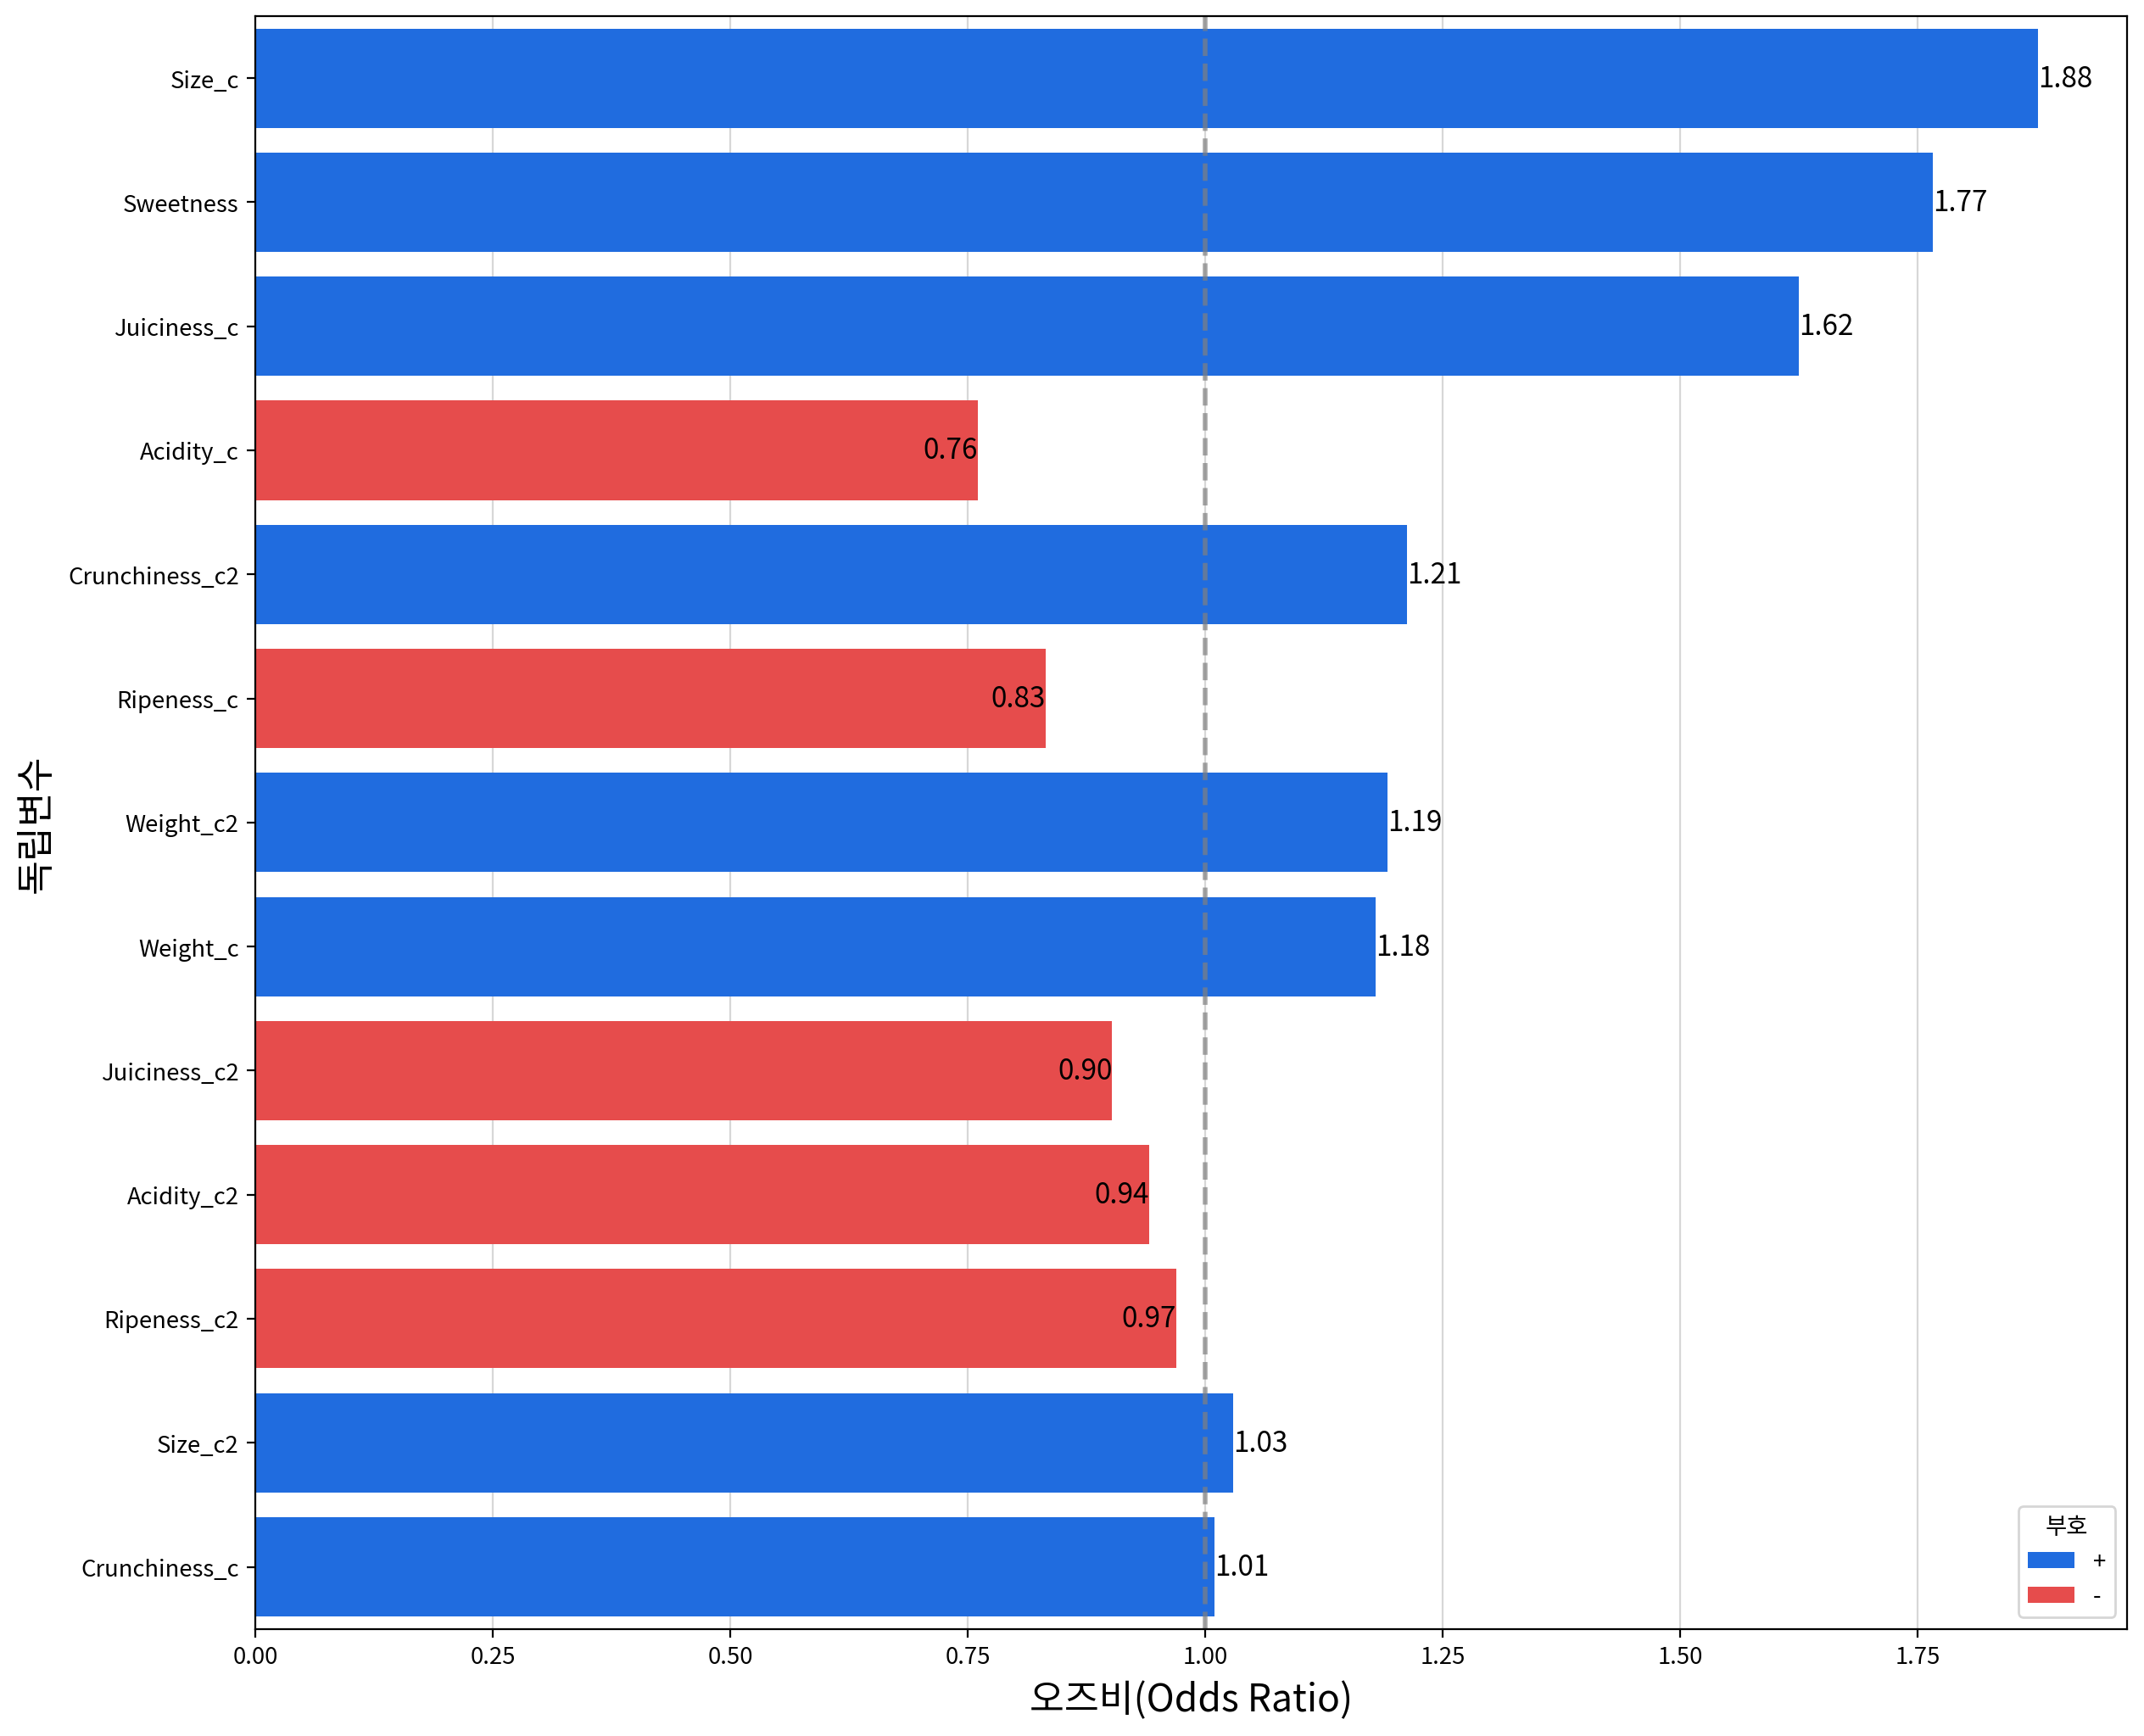

In [30]:
my_logit.plot_odds(final_fit, final_data)

##### 최종 모형 계수 해석

모형은 Sweetness 직선항과 나머지 6개 변수의 중심화 1차항·제곱항으로 구성되었다. LLR χ²≈1,899.19(p<0.001), McFadden Pseudo R²≈0.342였다. 이는 절편 모형 대비 적합 개선의 근거이며, 선형회귀의 설명분산 R² 또는 표본 외 예측력과 동일하지 않다.

Sweetness의 OR≈1.766은 다른 포함 변수가 같을 때 지표 1 증가에 따라 good 오즈가 약 76.6% 증가하는 조건부 관계다. 확률 증가율이나 당도를 조절한 실험 효과는 아니다.

제곱항이 있는 변수는 `z=x−평균`, `logit(p)=…+b1*z+b2*z²`로 읽는다. x가 1 증가할 때의 오즈비는 `exp(b1+b2*(2*z+1))`이므로 출발점 z에 따라 달라진다. 1차항 OR만으로 ‘항상 좋다/나쁘다’고 결론 내리지 않는다.

| 변수 | 1차항 / 제곱항 계수 | 해석의 범위 |
|---|---|---|
| Size | +0.629 / +0.029 | 로짓의 아래로 볼록한 곡선. 관측 범위와 꼭짓점을 함께 확인 |
| Weight | +0.165 / +0.176 | 아래로 볼록. 최저점은 반드시 평균이 아님 |
| Crunchiness | +0.010 / +0.192 | 1차항 비유의라도 제곱항을 포함한 곡선 관계가 존재할 수 있음 |
| Juiciness | +0.485 / −0.103 | 위로 볼록. 증가·감소 방향은 출발 수준에 따라 달라짐 |
| Ripeness | −0.184 / −0.031 | 위로 볼록. 전 구간에서 단조 감소라고 단정하지 않음 |
| Acidity | −0.274 / −0.061 | 위로 볼록. 단일 OR로 전체 범위를 설명하지 않음 |

계수의 부호·유의성은 저장된 출력과 일치한다. 관측 범위 밖으로 외삽하거나 가공된 지표를 실제 선별기 기준으로 환산하지 않는다.

#### 4. 분류 성능 평가

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),1555,441
실제 1 (Positive),392,1612


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,TPR)","위양성률(Fallout,FPR)","특이성(Specificity,TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
Performance,0.792,0.785,0.804,0.221,0.779,0.795,0.868,우수,14.500


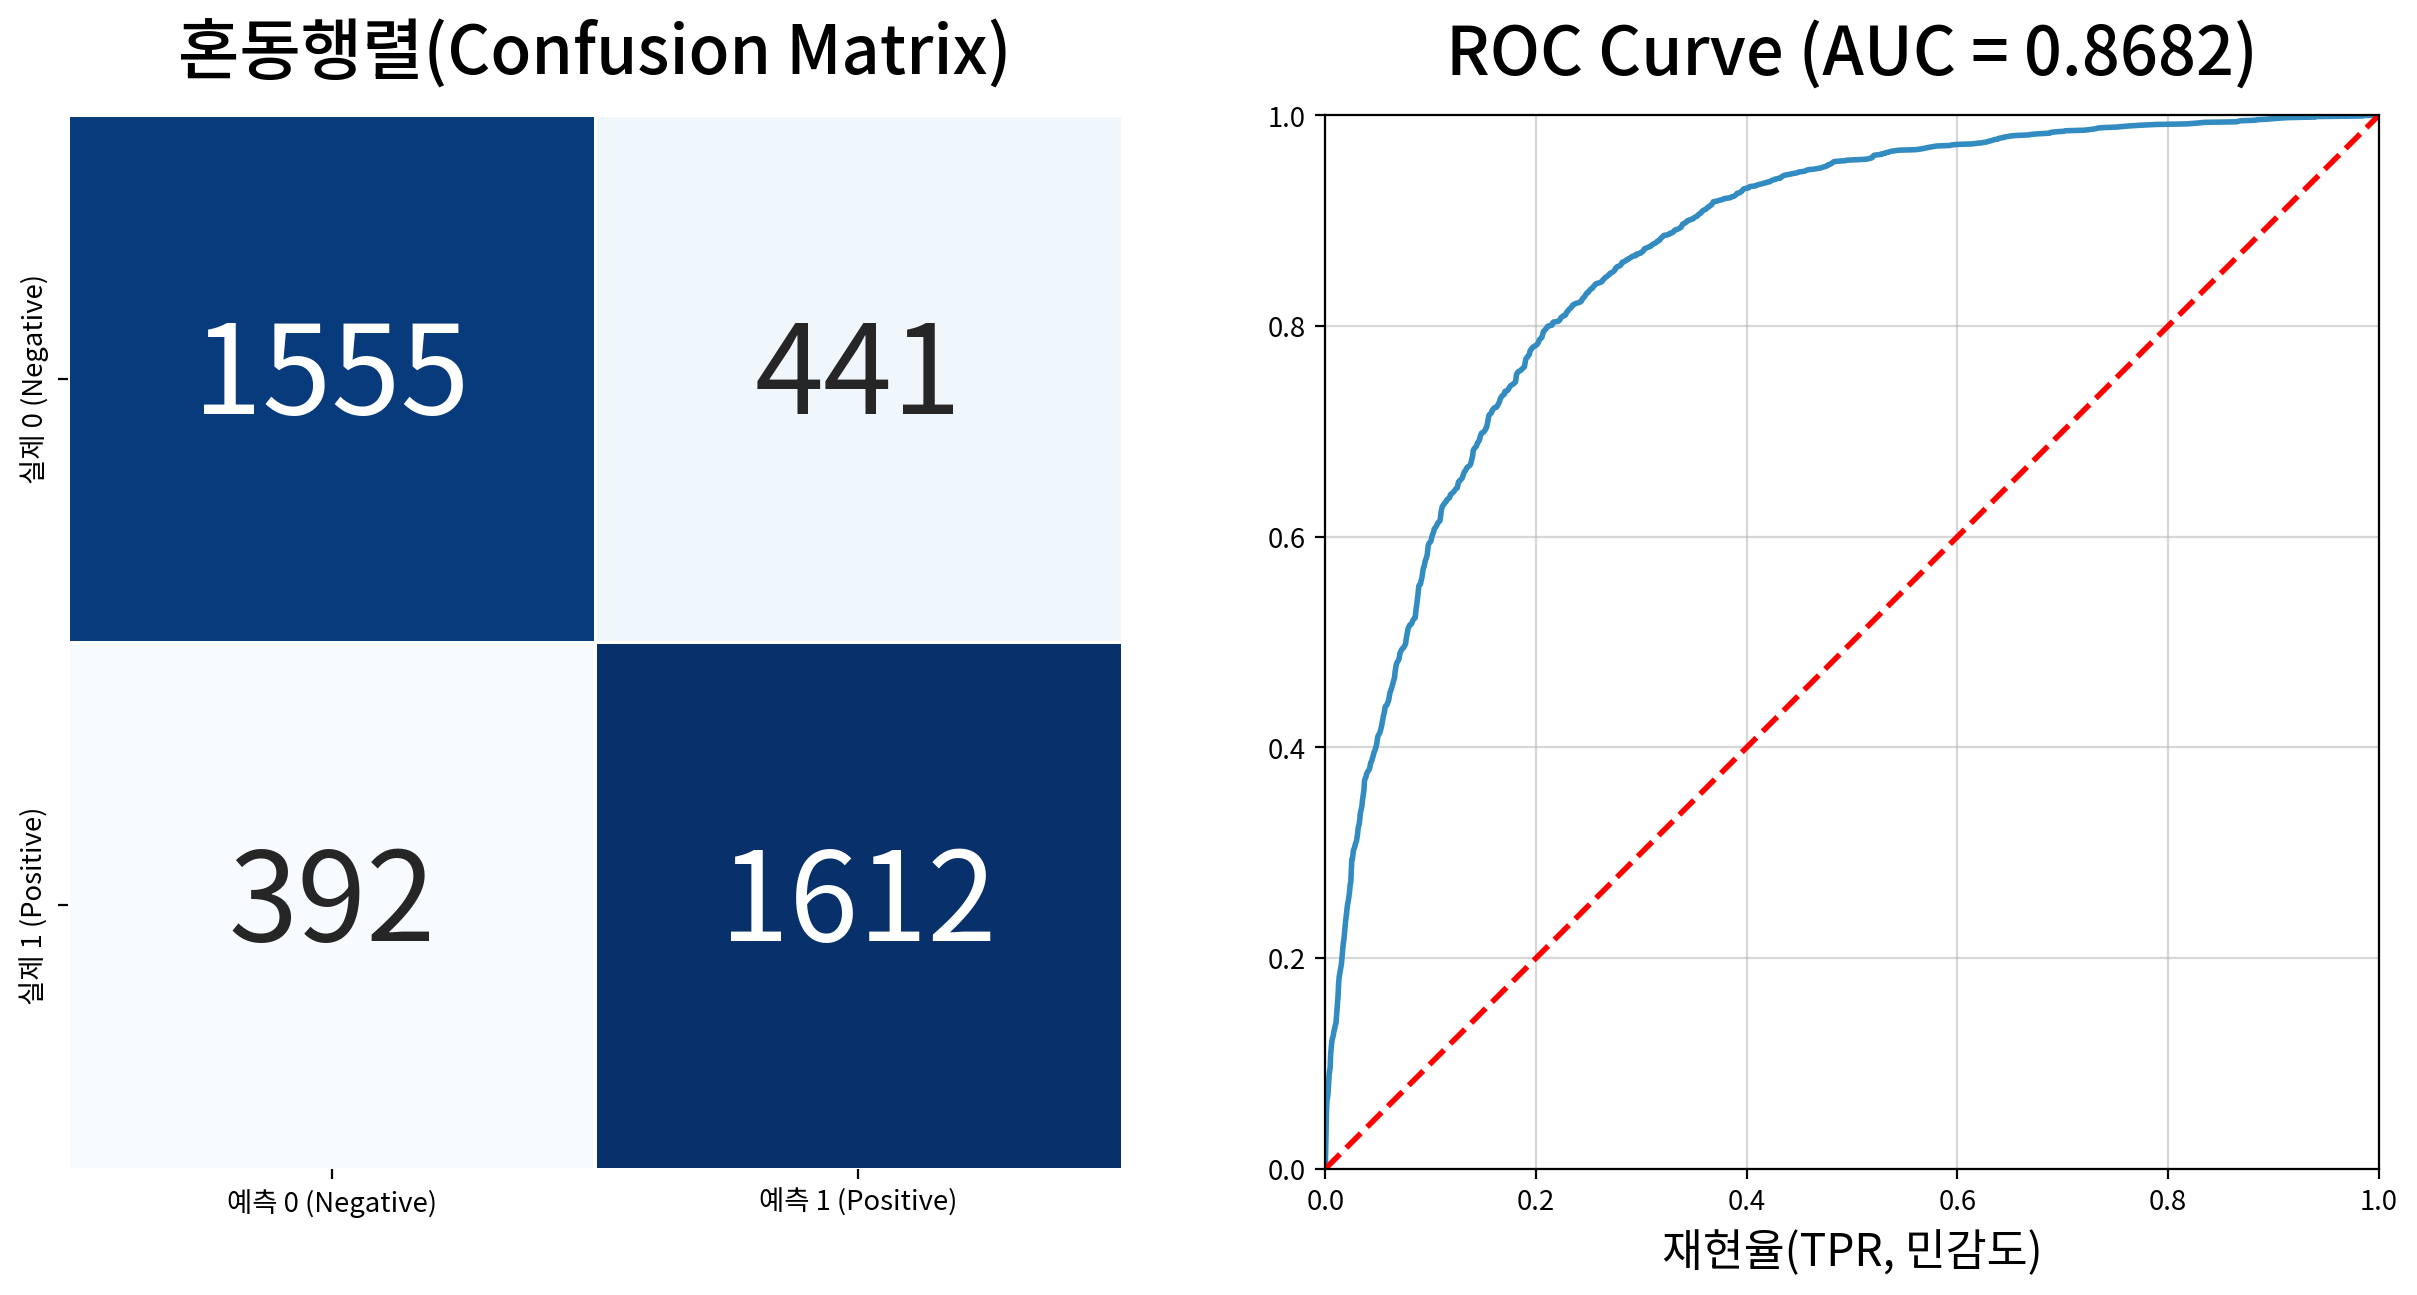

In [31]:
my_logit.report_performance(final_fit)

##### 분류 성능 해석

임계값 0.5에서 4,000건 중 3,167건을 맞혔다. 정확도 **79.18%**, 정밀도 **78.52%**, 재현율 **80.44%**, 특이도 **77.91%**, F1 **0.795**, ROC-AUC **0.868**이다. 실제 good을 놓친 FN은 392건, bad를 good으로 잘못 분류한 FP는 441건이었다.

정밀도는 good 예측 중 실제 good 비율, 재현율은 실제 good 중 찾아낸 비율이다. AUC는 점수의 순위 구분력이며 확률 자체의 보정 정도를 뜻하지 않는다. 모두 적합에 사용한 동일 표본에서 계산했으므로 새 사과에서의 검증 성능으로 보고하지 않는다.

#### 5. 임계값 조정

- 임계값 0.5는 관례일 뿐 **정답이 아니다.** 목적에 따라 조정한다.

In [32]:
my_logit.report_threshold(final_fit)

,정확도,정밀도,재현율,F1,놓친 1(FN),잘못 잡은 0(FP)
임계값,,,,,,
0.300,0.765,0.699,0.932,0.799,137,803
0.400,0.784,0.740,0.875,0.802,250,615
0.500,0.792,0.785,0.804,0.795,392,441
0.600,0.779,0.822,0.713,0.764,575,309
0.700,0.747,0.857,0.594,0.702,813,198


##### 임계값과 오류의 교환관계

비교 후보 중 정확도는 0.5에서 0.792, F1은 0.4에서 0.802로 높았다. 임계값을 0.5 → 0.4로 낮추면 FN은 392 → 250건으로 줄지만 FP는 441 → 615건으로 늘어난다. 0.5 → 0.7로 높이면 FP는 441 → 198건으로 줄지만 FN은 392 → 813건으로 늘어난다.

good 출하의 오분류를 줄이는 목적과 좋은 사과를 제외하는 손실을 줄이는 목적은 상충한다. 실제 비용과 별도 검증이 없으므로 0.4를 보편적인 최적값이라고 확정하지 않는다. 아래 종합 해석에서 비용 관점의 교환관계를 정리한다.

### 분석 범위와 주의사항

- 로짓 선형성 진단의 자동 처방과 모형 선택에 같은 데이터를 반복 사용했다. 최종 6개 제곱항은 표본 내 적합을 개선했으나 과적합 가능성을 배제하지 않는다.
- 표본 내 성능과 표본 외 검증 성능을 구분한다. 별도 검증, 임계값의 운영 비용 분석은 이번 분석에 포함하지 않았다.
- 가공 지표의 물리적 단위·변환 공식과 품질 라벨의 세부 판정 기준은 이 분석에서 확인한 범위가 제한적이다. 실무 선별 규격이나 인과효과로 바꾸어 해석하지 않는다.
- 로짓 선형성의 비기각이나 DW 참고값을 가정이 완전히 입증되었다는 의미로 쓰지 않는다.

<a id="conclusion"></a>

## 3. 종합 결과 해석

### 1. 단독 비교만으로는 놓치는 관계가 있었다

good 2,004건과 bad 1,996건으로 클래스 비율은 거의 같았고, 중복·결측은 없었다. 식별자 A_id를 제외한 수치형 특성 7개를 모두 후보로 유지했다. Size·Sweetness·Juiciness·Ripeness는 집단 비교에서 유의했고, Weight·Acidity·Crunchiness는 유의한 차이를 발견하지 못했다.

그러나 다른 변수를 함께 포함한 기준선에서는 Weight와 Acidity도 유의했다. 단독 분포 비교와 다른 특성을 고정한 조건부 관계가 서로 다른 질문임을 보여준다. Crunchiness는 기준선 직선항에서도 p≈0.253이었지만, 로짓 선형성 진단과 제곱항 추가 이후 곡선 관계가 드러났다. **처음의 비유의성만으로 변수를 삭제하지 않은 판단이 중요했다.** 유의성 변화만으로 억제효과의 원인이나 품질의 인과적 결정요인을 확정하지는 않는다.

### 2. 무엇이 모형 적합을 개선했는가

| 비교 대상 | 설명항 수 | 정확도 | F1 | ROC-AUC | AIC |
|---|---:|---:|---:|---:|---:|
| 0_기준선 | 7 | 0.749 | 0.753 | 0.824 | 4129.557 |
| 1_후진소거 | 6 | 0.750 | 0.754 | 0.824 | 4128.863 |
| 2_이상치대체 | 6 | 0.749 | 0.754 | 0.823 | 4136.292 |
| 3_정규화 | 6 | 0.749 | 0.754 | 0.823 | 4136.292 |
| **4_가정반영 — 최종** | **13** | **0.792** | **0.795** | **0.868** | **3673.968** |
| 5_가정반영+후진소거 | 12 | 0.791 | 0.794 | 0.868 | 3672.041 |
| 6_가정반영+이상치대체 | 12 | 0.793 | 0.796 | 0.868 | 3677.811 |
| 7_가정반영+정규화 | 12 | 0.793 | 0.796 | 0.868 | 3677.811 |

가정 미반영 0~3번의 AUC는 약 0.823~0.824, 반영 4~7번은 약 0.868이었다. 이 비교에서는 후진소거·이상치 대체·표준화 자체보다 **직선항만으로 부족했던 관계를 제곱항으로 표현한 모형의 적합 개선**이 두드러졌다. 정확도는 기준선 대비 약 4.3%p 높아졌다. 전처리를 많이 할수록 좋아진다는 결론이 아니며, 동일 표본에서 선택·평가한 개선이다.

Sweetness를 제외한 6개 특성에 중심화 1차항과 제곱항이 적용되었다. 모든 체크포인트에서 VIF를 점검했고, 최종 모형의 최대 VIF는 약 1.609였다. 파생항을 포함해 강한 공선성 신호는 크지 않았지만, 이 수치가 모형 전체의 타당성을 보장하지는 않는다.

### 3. 자동 1순위 대신 4번을 선택한 이유

자동 비교는 AUC가 근소한 모형 중 설명항 수가 적은 5번을 우선했다. 하지만 5번은 Crunchiness의 제곱항을 남기고 1차항을 제거했다. 최종 4번의 Crunchiness 1차항은 p≈0.787로 비유의하나 제곱항은 p<0.001이었다. 제곱항을 유지할 때 그 짝인 1차항도 함께 두는 계층 원칙에 따라 4번을 선택했다.

4번과 5번의 AIC 차이는 약 **1.927**로 작고 AUC는 소수 셋째 자리에서 같았다. 6·7번의 정확도가 0.793으로 조금 높더라도, 같은 계층 원칙과 작은 차이를 함께 고려했다. **모든 지표에서 4번이 최고라고 주장하는 것이 아니라, 적합도와 모형식의 해석 가능성을 함께 고려한 선택**이다. 작은 차이로 통계적 동등성까지 입증한 것은 아니다.

### 4. 계수는 변수의 형태에 맞게 해석했다

Sweetness는 제곱항 없이 남았고 OR≈1.766(95% 신뢰구간 약 1.664~1.873)이었다. 다른 포함 특성이 같은 경우 지표 1 증가에 따라 good 오즈가 약 76.6% 증가하는 조건부 관계다. 확률이 76.6%p 오르거나 실제 당도를 조절한 인과효과라는 뜻은 아니다.

나머지 변수는 중심화한 값 z에 대해 `b1*z+b2*z²`를 함께 읽어야 한다. 특히 Crunchiness는 양의 제곱항 계수 약 0.192로 로짓이 아래로 볼록한 형태를 보였다. 직선항만 보면 약했던 관계를 곡선으로 표현한 것이다. 모든 구간에서 아삭함을 늘릴수록 좋다는 주장이나 물리적 선별 기준으로 바꿀 수는 없다. 단일 계수의 OR 또는 표준화 계수 크기만으로 원변수 전체의 중요도 순위를 확정하지 않는다.

### 5. 실제로 어떤 오분류가 발생했는가

임계값 0.5에서 실제 good 2,004건 중 **1,612건을 good으로 분류했고 392건을 놓쳤다(FN)**. 실제 bad 1,996건 중 **1,555건을 bad로 분류했고 441건을 good으로 잘못 분류했다(FP)**. 정분류는 3,167건, 오분류는 833건이었다.

| 임계값 | 정확도 | 정밀도 | 재현율 | F1 | 놓친 good(FN) | good으로 잘못 분류한 bad(FP) |
|---|---:|---:|---:|---:|---:|---:|
| 0.3 | 0.765 | 0.699 | 0.932 | 0.799 | 137 | 803 |
| 0.4 | 0.784 | 0.740 | 0.875 | 0.802 | 250 | 615 |
| 0.5 | 0.792 | 0.785 | 0.804 | 0.795 | 392 | 441 |
| 0.6 | 0.779 | 0.822 | 0.713 | 0.764 | 575 | 309 |
| 0.7 | 0.747 | 0.857 | 0.594 | 0.702 | 813 | 198 |

0.5에서 0.4로 낮추면 놓치는 good은 **142건 감소**하지만, good으로 잘못 분류하는 bad는 **174건 증가**한다. 0.7로 높이면 잘못 통과시키는 bad는 **243건 감소**하지만 놓치는 good은 **421건 증가**한다. 실제 선별 업무를 가정한다면 잘못 출하하는 비용과 좋은 사과를 제외하는 비용에 따라 선택이 달라진다. 이 비용을 측정하지 않았으므로 특정 임계값을 최적 운영값으로 확정하지 않는다. F1 최대 0.802는 비교한 후보 중 0.4에서 얻은 표본 내 값이다.

### 6. 한계와 회고

변환·변수·임계값 선택과 평가에 같은 4,000건을 사용했다. 따라서 성능은 낙관적일 수 있으며 실제 적용을 위해서는 별도 검증이 필요하다. 이번 프로젝트에 새로운 분할이나 알고리즘을 추가하지는 않았다. 반복 탐색 후의 통상적인 p값을 전체 탐색 과정을 반영한 확증 검정으로 취급하지 않는다.

DW≈2.022는 주어진 행 순서에 대한 잔차 패턴 참고값이지 독립성의 증명이 아니다. 지표의 물리적 단위·가공 공식과 라벨 판정의 세부 기준, 농장·수확 묶음 등 표본 수집 구조는 이 분석에서 확인한 범위가 제한적이다. 결과를 실제 선별 규격이나 인과효과로 확장하지 않는다.

이 프로젝트에서 얻은 핵심은 **단독 검정 → 모형 가정 진단 → 비교 → 선택 근거 → 오류의 구체적 의미**를 연결하는 분석 흐름이다. 코드 실행이나 점수 제시에서 끝내지 않고, 비선형 관계를 놓치지 않는 변수 판단과 최종 선택의 이유·한계를 함께 설명했다.
